# Estimation of R 【FINO3版】
Rを求めて海表面情報を探索する試み。

In [1]:
# 依存パッケージをimport

import os

from gnssrefl.utils import check_environment, set_environment, get_sys
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pywt

# import gnssrefl functions
from gnssrefl.rinex2snr_cl import rinex2snr
from gnssrefl.gnssir_cl import gnssir

#@formatter:off
%matplotlib inline

## SNRファイルの読み込み

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# SNR ファイルのカラム名（マニュアル準拠）
SNR_COLUMNS_FULL = [
    "sat",              # 衛星番号
    "elev_deg",         # 仰角 [deg]
    "az_deg",           # 方位角 [deg]
    "sec_of_day",       # 秒（GPS time）
    "edot_deg_per_s",   # 仰角変化率 [deg/s]
    "snr_L6",           # S6 (L6) SNR [dB-Hz]
    "snr_L1",           # S1 (L1)
    "snr_L2",           # S2 (L2)
    "snr_L5",           # S5 (L5)
    "snr_L7",           # S7 (L7)
    "snr_L8",           # S8 (L8)
]


def read_snr_file_gz(path: Path) -> pd.DataFrame:
    """1つの .snr*.gz ファイルを読み込んで DataFrame を返す。"""
    df = pd.read_csv(
        path,
        sep=r"\s+",        # ← FutureWarning 回避
        header=None,
        comment="#",
        compression="gzip",
        engine="python",
    )
    n_cols = df.shape[1]
    df.columns = SNR_COLUMNS_FULL[:n_cols]
    return df


def load_snr_directory(year: int, station: str,
                       base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    /etc/gnssrefl/refl_code/{year}/snr/{station}/ 配下の
    .snr*.gz ファイルだけを全部読み込んで

    - snr_dict: {ファイル名: DataFrame}
    - snr_table: 全ファイルを縦結合した DataFrame
                 (year, station, doy, file などの情報付き)

    を返す。
    """
    snr_dir = Path(base_dir) / str(year) / "snr" / station

    if not snr_dir.is_dir():
        raise FileNotFoundError(f"ディレクトリが見つかりません: {snr_dir}")

    snr_files = sorted(snr_dir.glob("*.snr*.gz"))

    if not snr_files:
        print(f"*.snr*.gz が見つかりません: {snr_dir}")

    snr_dict = {}
    table_list = []

    for f in snr_files:
        df = read_snr_file_gz(f)
        snr_dict[f.name] = df

        # ファイル名から DOY を推定（例: calc2770.20.snr66.gz）
        name_no_gz = f.name[:-3] if f.name.endswith(".snr88.gz") else f.name
        stem = name_no_gz.split(".")[0]   # "calc2770"
        doy = int(stem[len(station):len(station) + 3])  # "277"

        df2 = df.copy()
        df2["year"] = year
        df2["station"] = station
        df2["file"] = f.name
        df2["doy"] = doy
        table_list.append(df2)

    if table_list:
        snr_table = pd.concat(table_list, ignore_index=True)
    else:
        snr_table = pd.DataFrame()

    return snr_dict, snr_table

def snrread_main(year: int,
         station: str,
         snr_dict_existing=None,
         base_dir: str = "/etc/gnssrefl/refl_code"):
    """
    - Jupyter で既に snr_dict を作っているなら snr_dict_existing を渡す
    - そうでなければディレクトリから読み込む

    戻り値:
        snr_dict, snr_table
    """
    if snr_dict_existing is None:
        snr_dict, snr_table = load_snr_directory(year, station, base_dir=base_dir)
    else:
        # 既存の snr_dict から snr_table だけ再構成したい場合など
        snr_dict = snr_dict_existing
        # ここで snr_table を組み立て直すなら、上の build 処理を使い回すイメージ
        # 必要なら別関数に分けてもよい
        rows = []
        for fname, df in snr_dict.items():
            name_no_gz = fname[:-3] if fname.endswith(".gz") else fname
            stem = name_no_gz.split(".")[0]
            doy = int(stem[len(station):len(station) + 3])

            tmp = df.copy()
            tmp["year"] = year
            tmp["station"] = station
            tmp["file"] = fname
            tmp["doy"] = doy
            rows.append(tmp)
        snr_table = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

    return snr_dict, snr_table


## コヒーレント・インコヒーレント比率Rの異方性を検証

読み込み完了: 5729705 rows


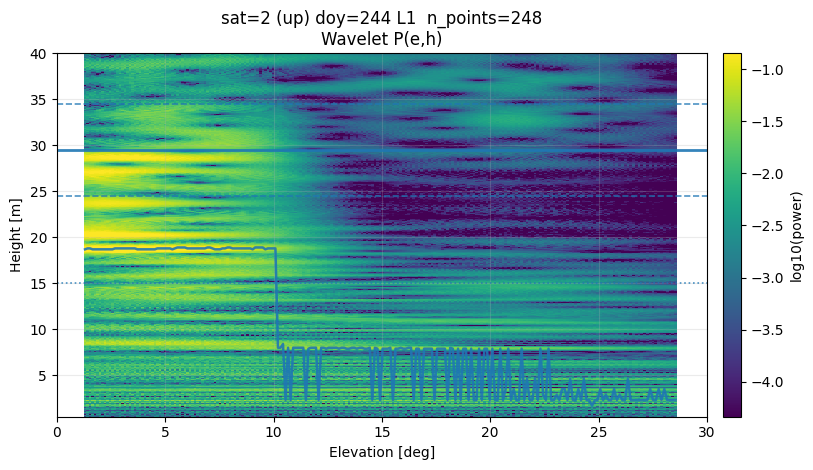

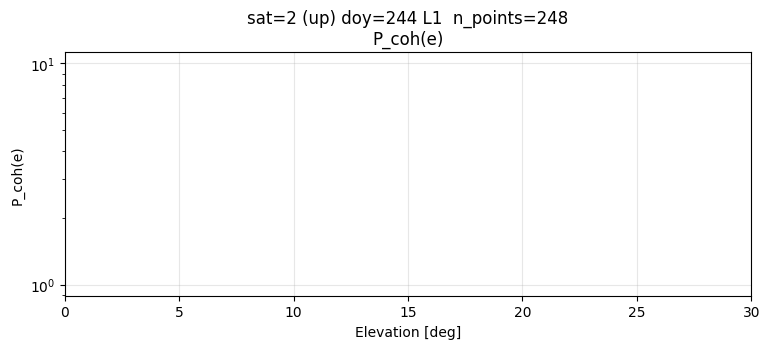

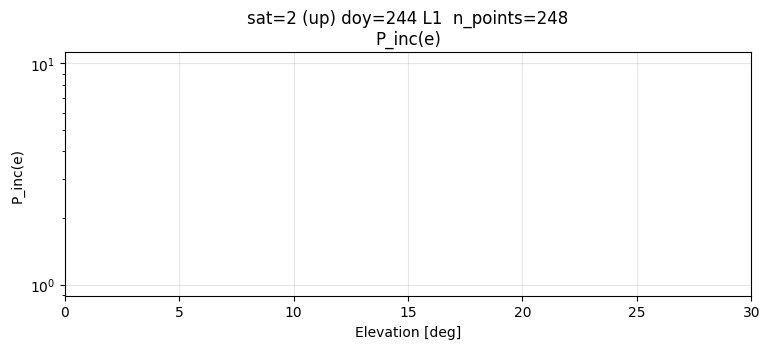

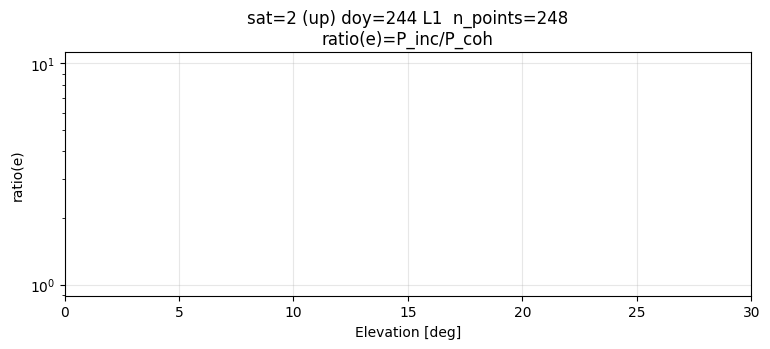

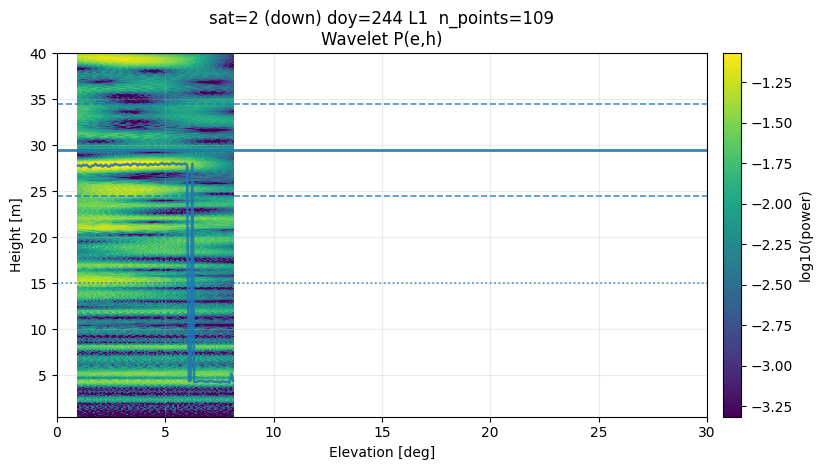

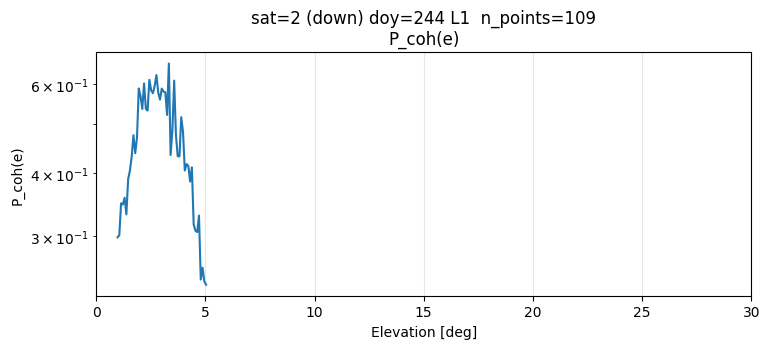

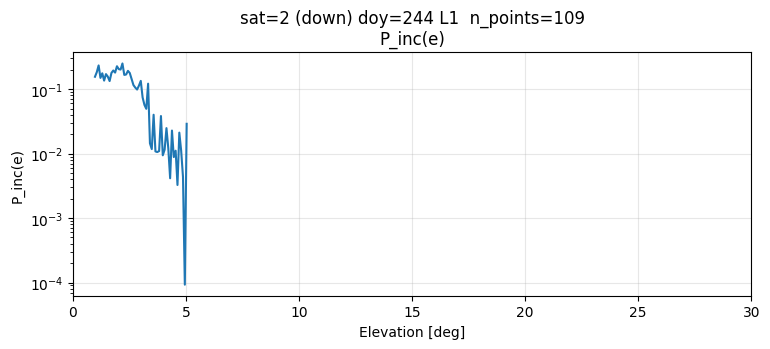

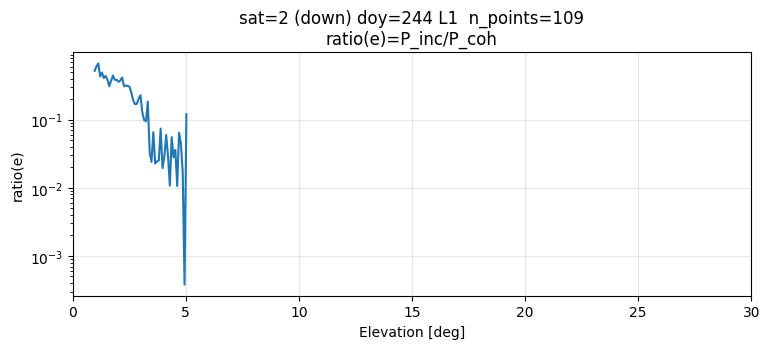

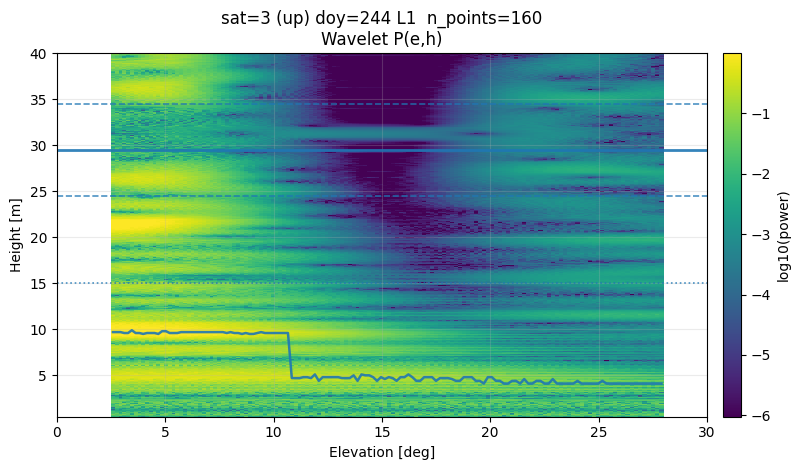

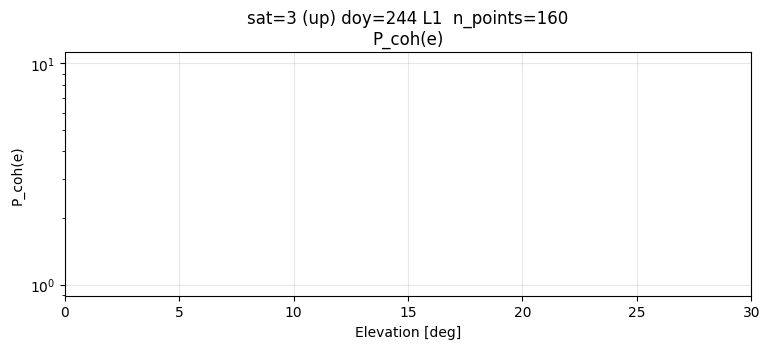

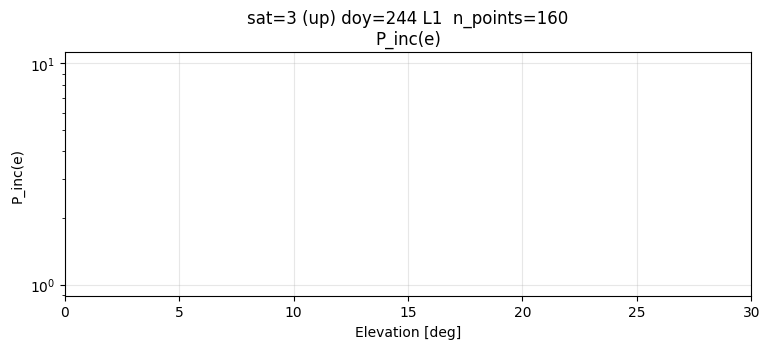

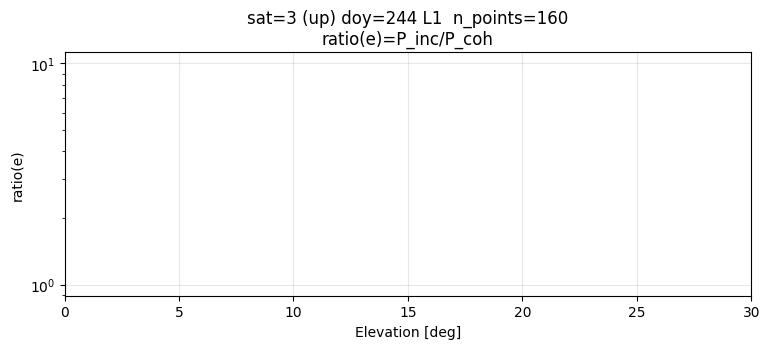

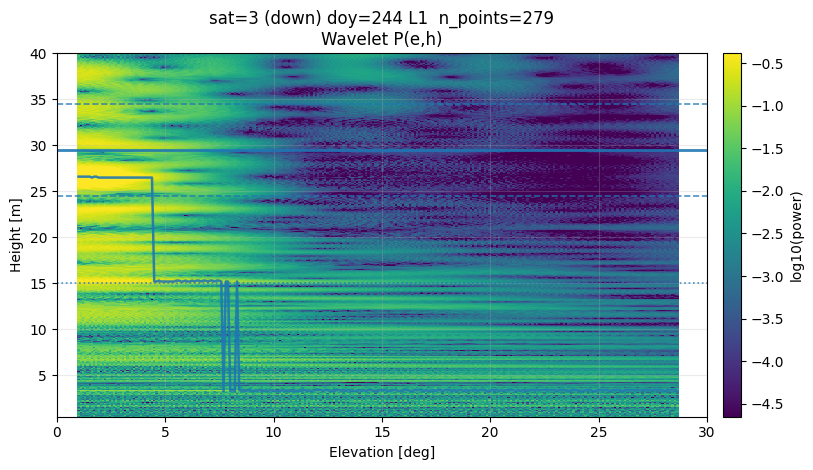

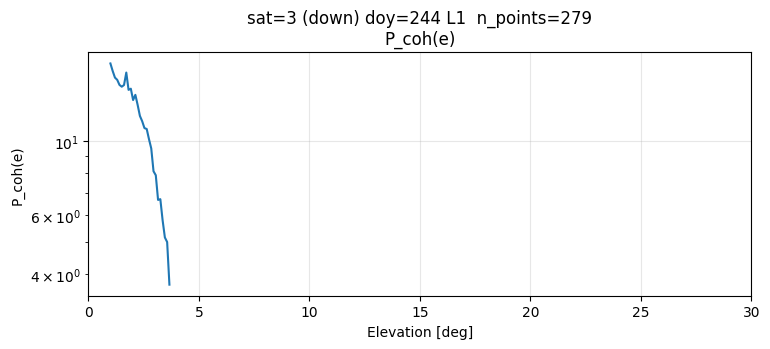

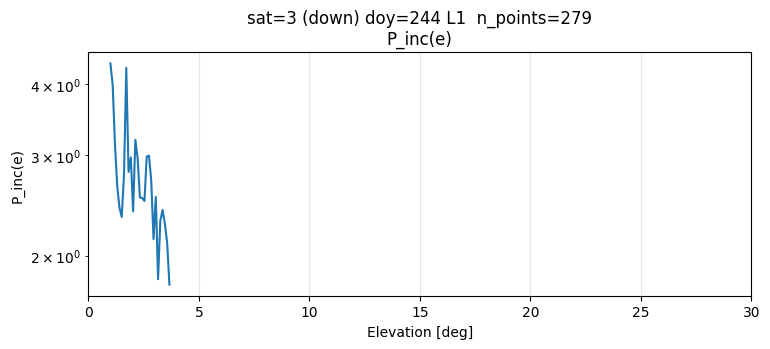

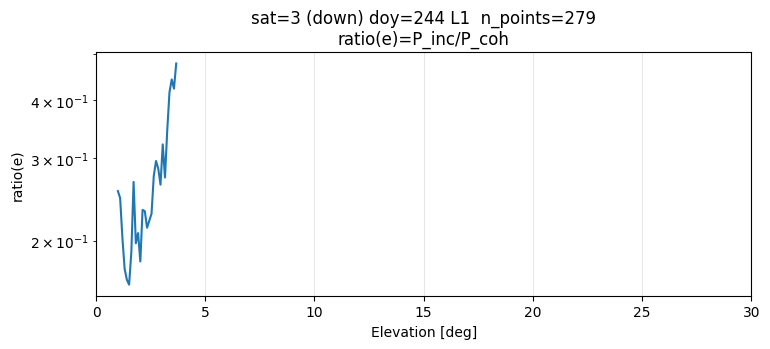

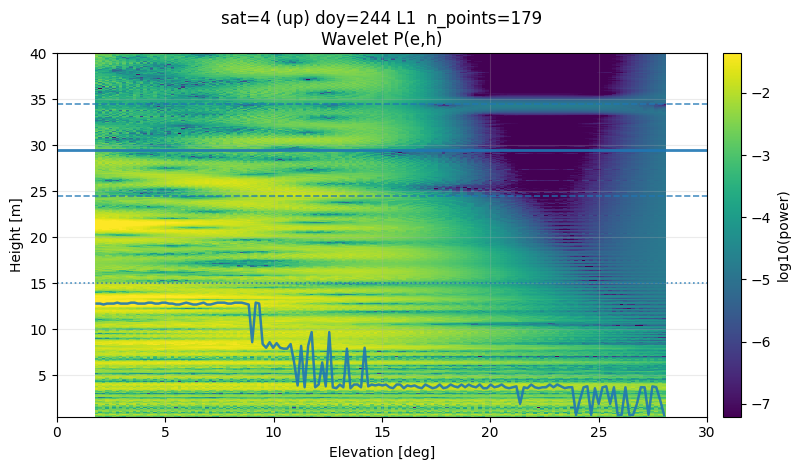

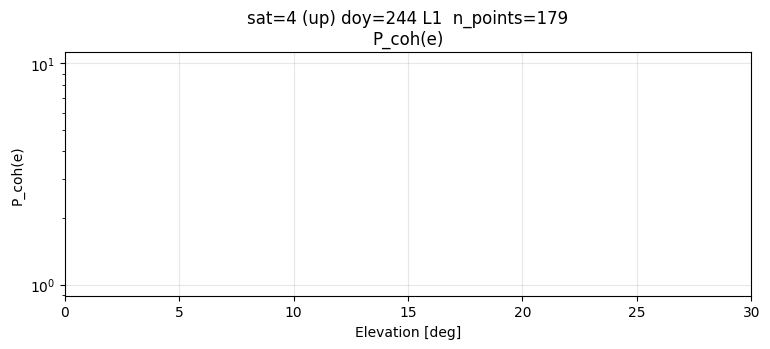

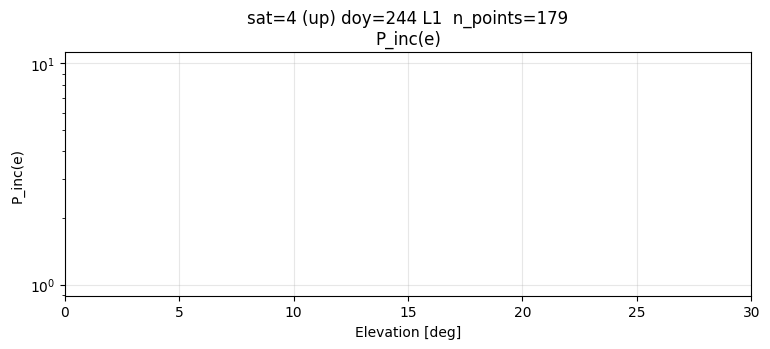

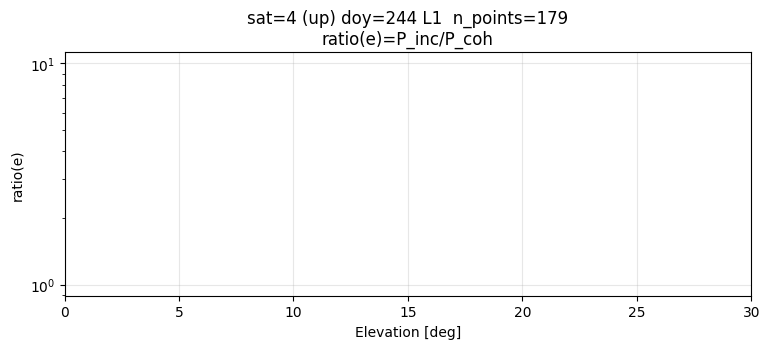

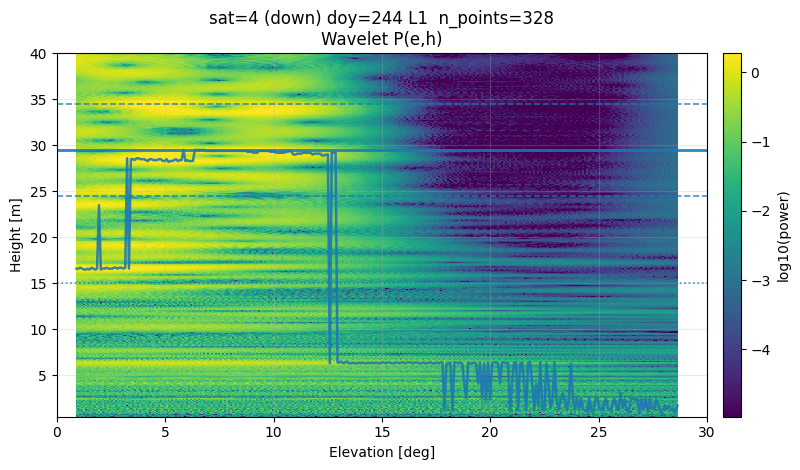

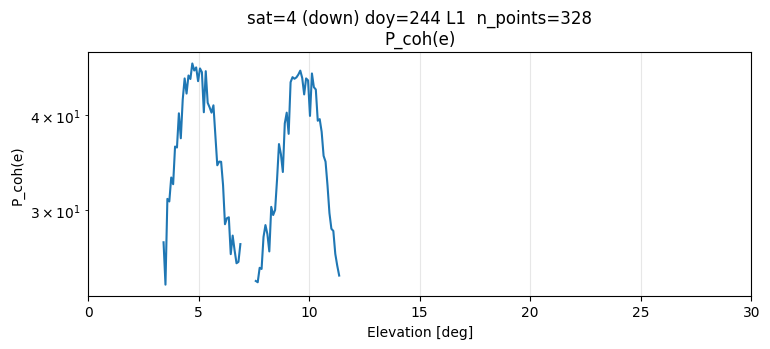

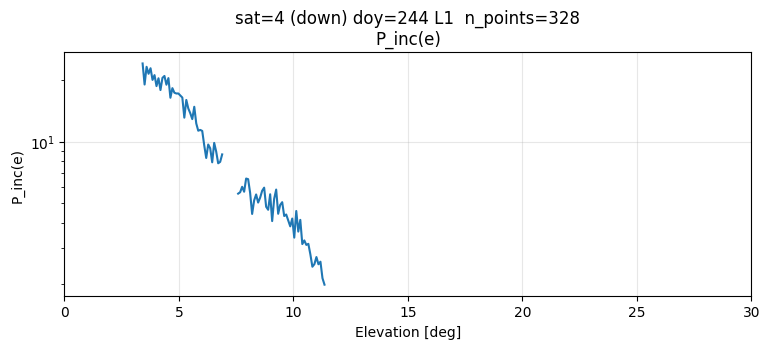

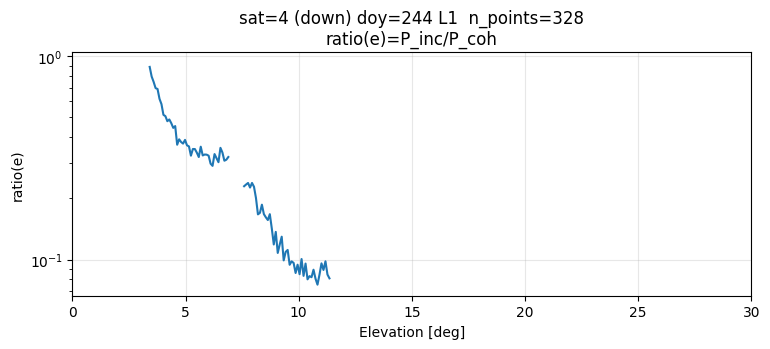

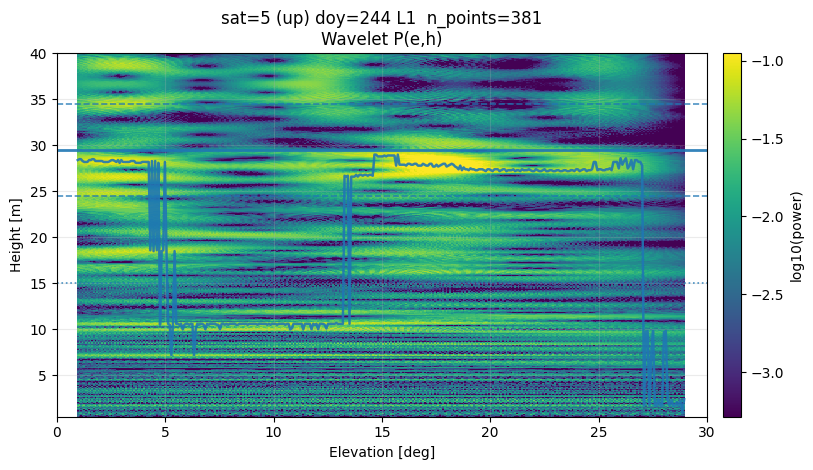

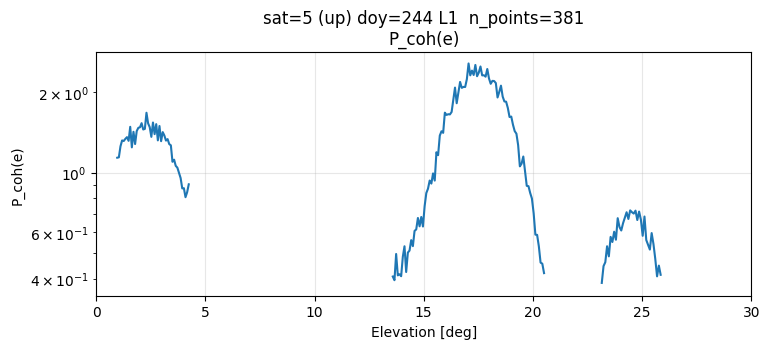

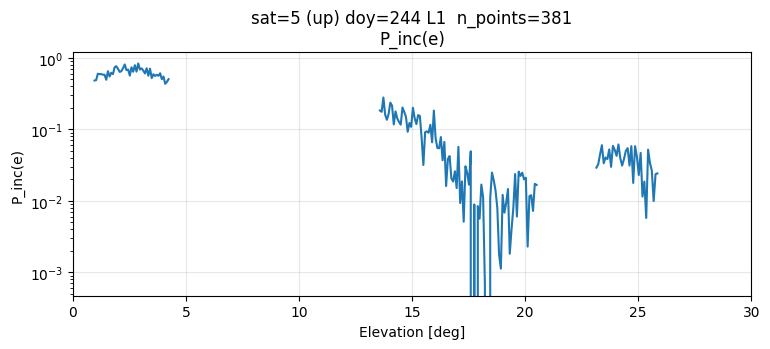

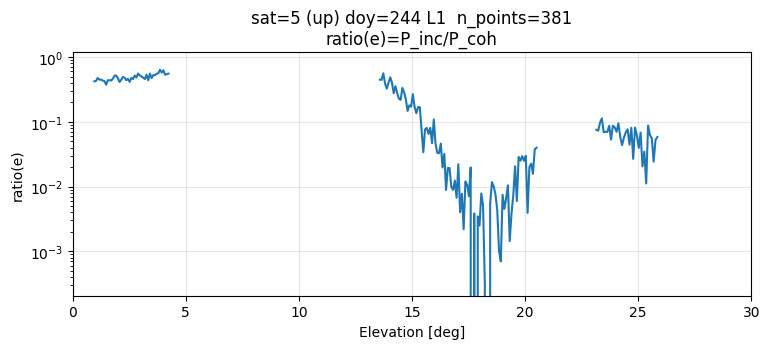

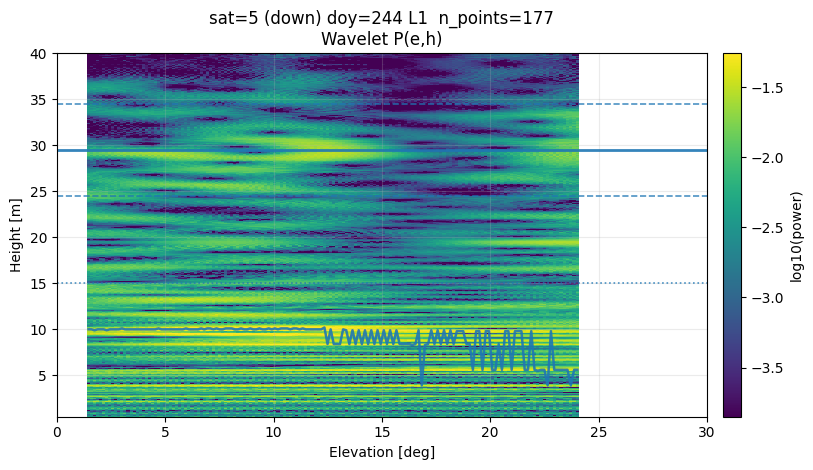

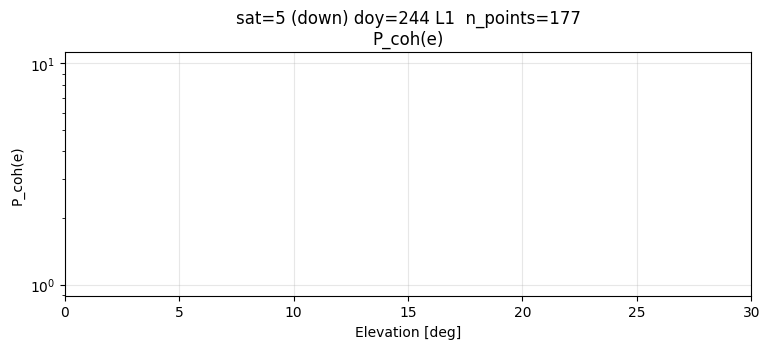

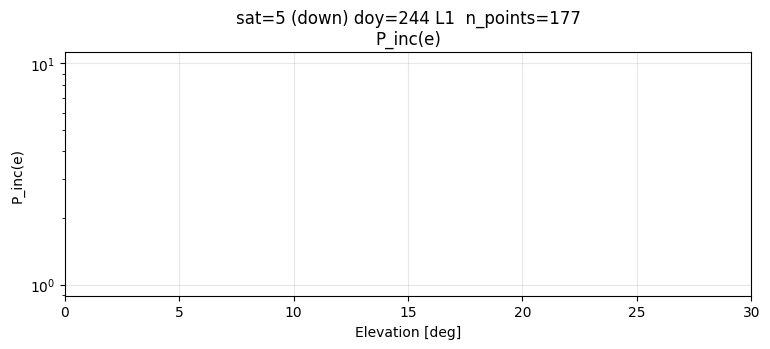

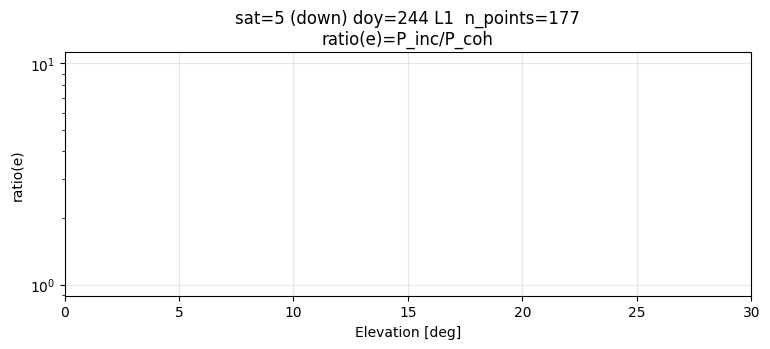

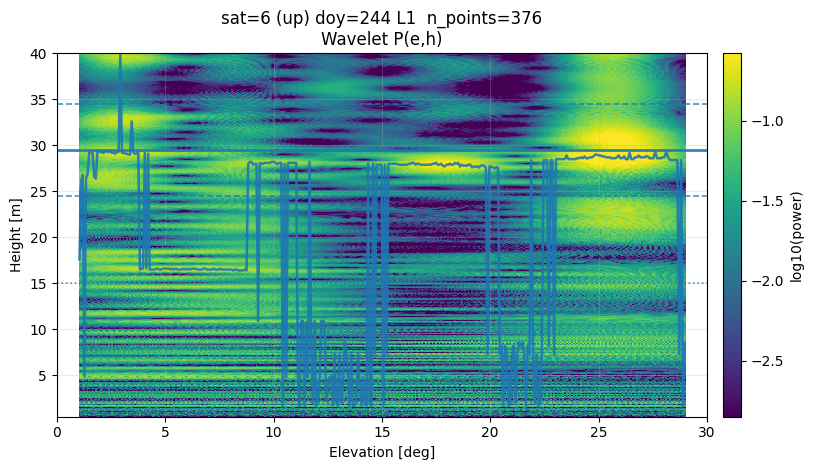

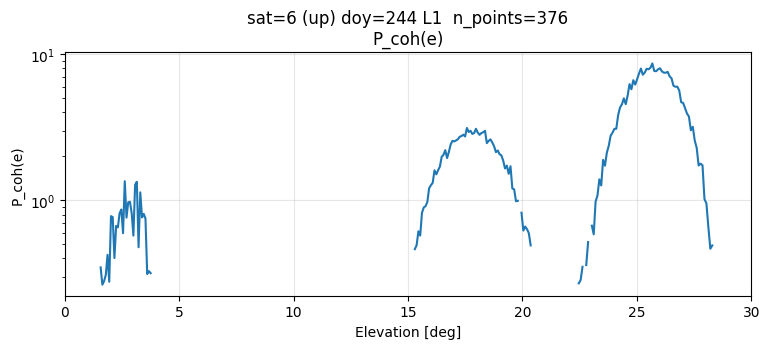

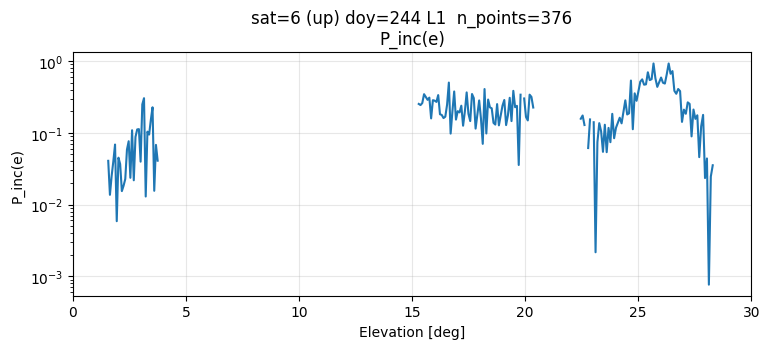

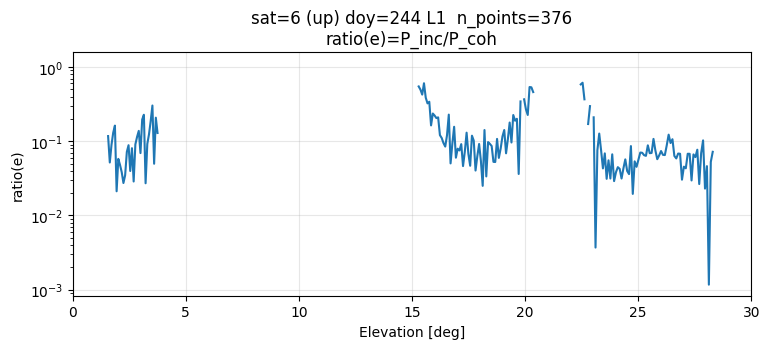

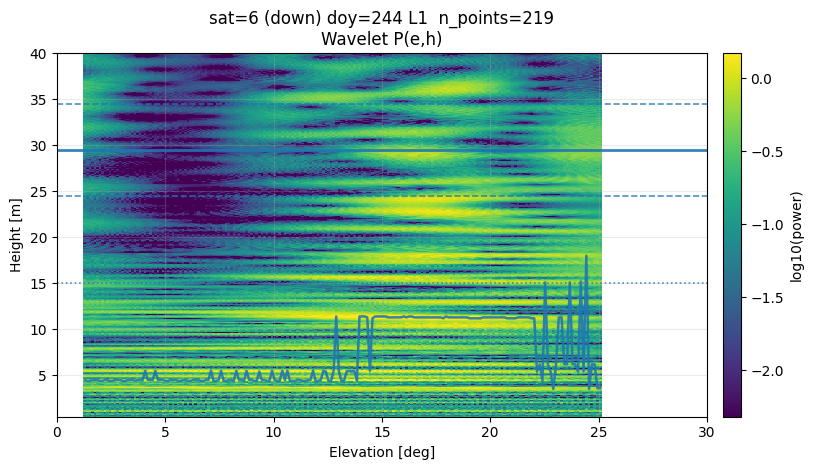

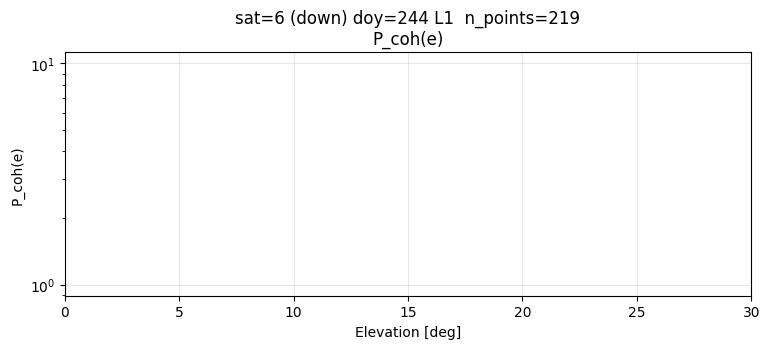

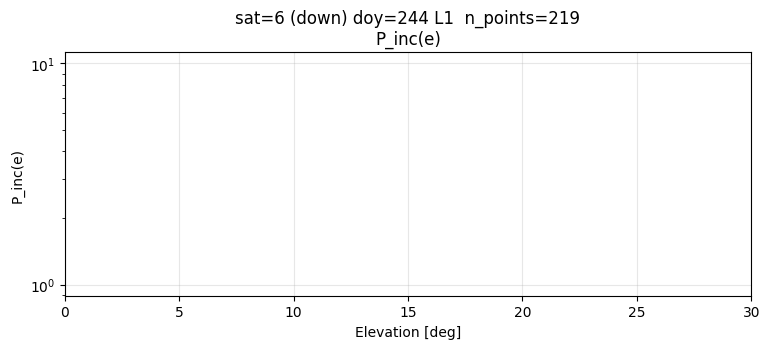

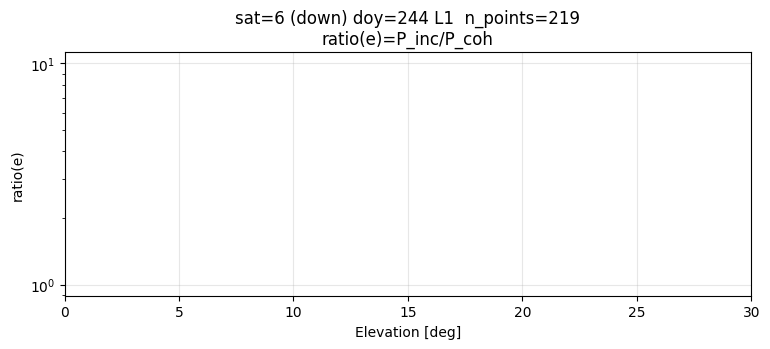

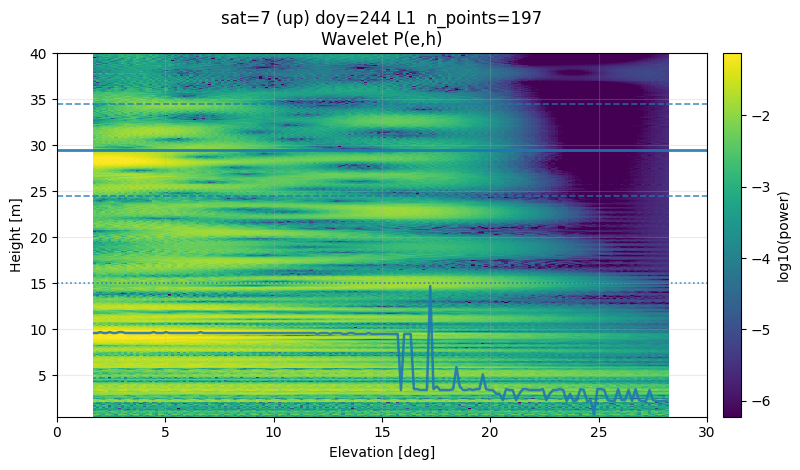

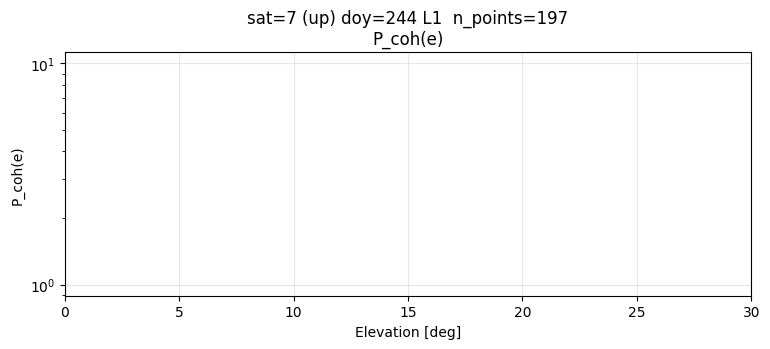

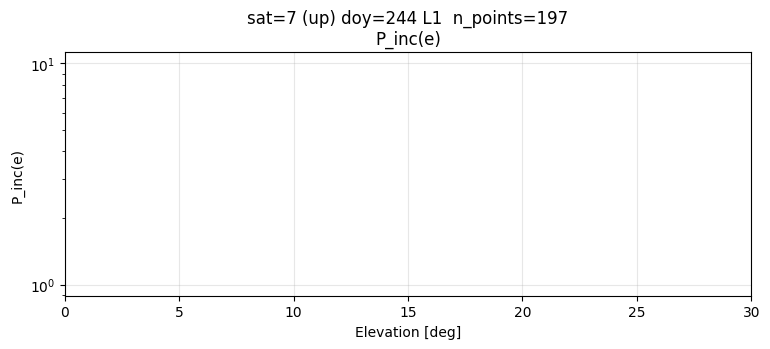

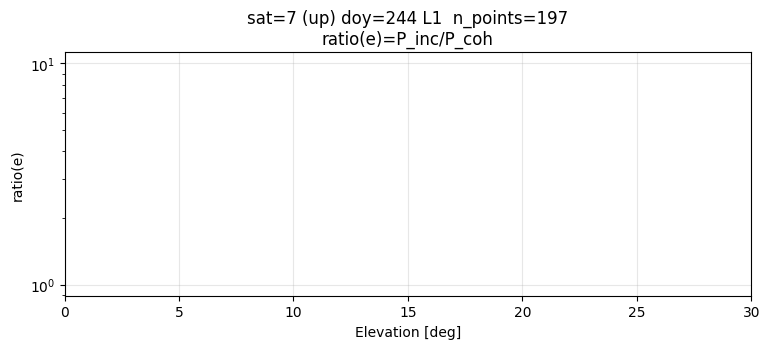

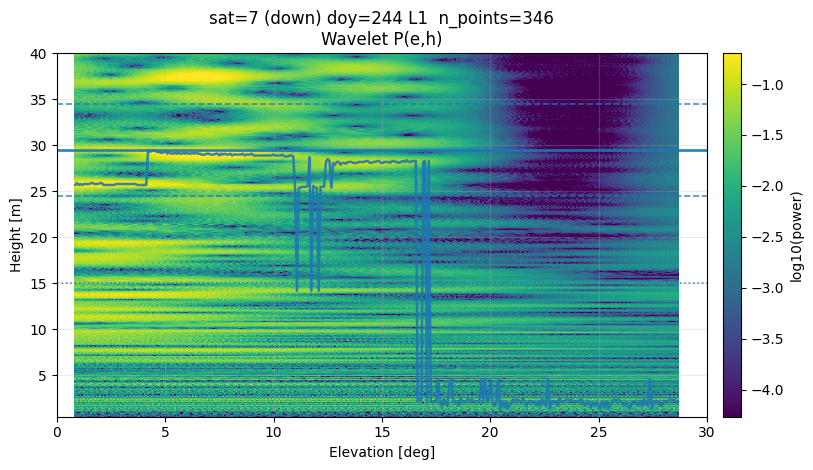

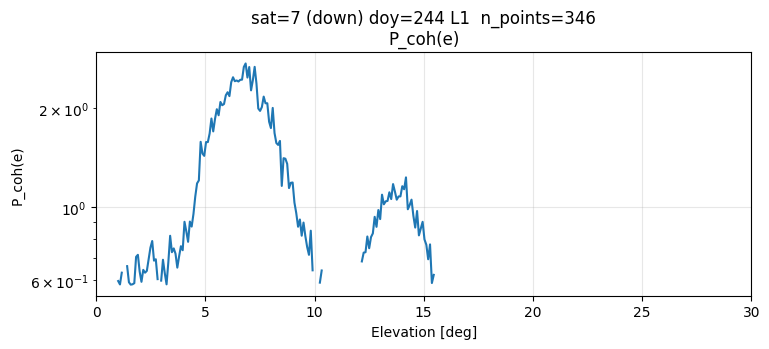

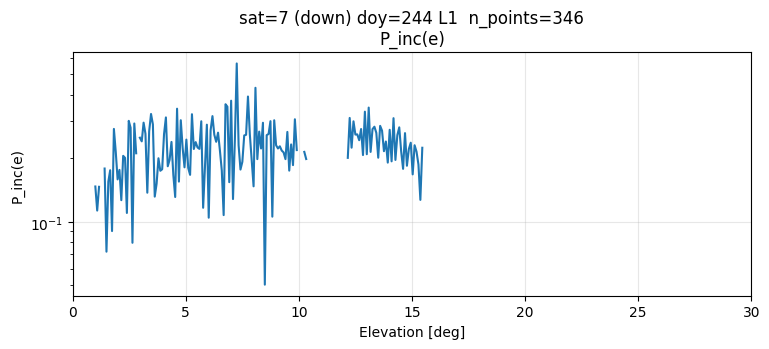

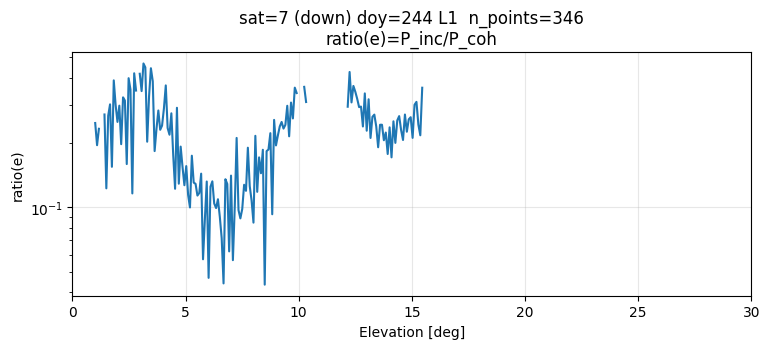

drop_stat: {'no_data': 1, 'short': 0, 'wavelet_fail': 0, 'too_few_valid': 33}


,year,doy,station,signal,az_min,az_max,direction,band_min,band_max,ok,...,axis_ratio,phi_deg,n_fit,n_all,sel_n_in,sel_n_after_cap,sel_n_keep,sel_r_max_trust,sel_method,sel_reason
0,2024,244,tgf3,L1,225,135,both,0,5,True,...,3.379884,130.784373,9,21,22.0,21.0,21,1.0,madlog,NaN
1,2024,244,tgf3,L1,225,135,both,5,10,False,...,NaN,NaN,5,16,16.0,16.0,16,1.0,madlog,NaN
2,2024,244,tgf3,L1,225,135,both,10,15,False,...,NaN,NaN,3,13,13.0,13.0,13,1.0,madlog,NaN
3,2024,244,tgf3,L1,225,135,both,15,20,False,...,NaN,NaN,3,11,12.0,12.0,11,1.0,madlog,NaN
4,2024,244,tgf3,L1,225,135,both,20,25,False,...,NaN,NaN,2,6,6.0,6.0,6,1.0,madlog,NaN
5,2024,244,tgf3,L1,225,135,both,25,30,False,...,NaN,NaN,0,7,7.0,7.0,7,1.0,madlog,NaN
6,2024,244,tgf3,L1,225,135,up,0,5,False,...,NaN,NaN,4,11,11.0,11.0,11,1.0,madlog,NaN
7,2024,244,tgf3,L1,225,135,up,5,10,False,...,NaN,NaN,2,7,7.0,7.0,7,1.0,madlog,NaN
8,2024,244,tgf3,L1,225,135,up,10,15,False,...,NaN,NaN,1,7,7.0,7.0,7,1.0,madlog,NaN
9,2024,244,tgf3,L1,225,135,up,15,20,False,...,NaN,NaN,2,7,8.0,8.0,7,1.0,madlog,NaN


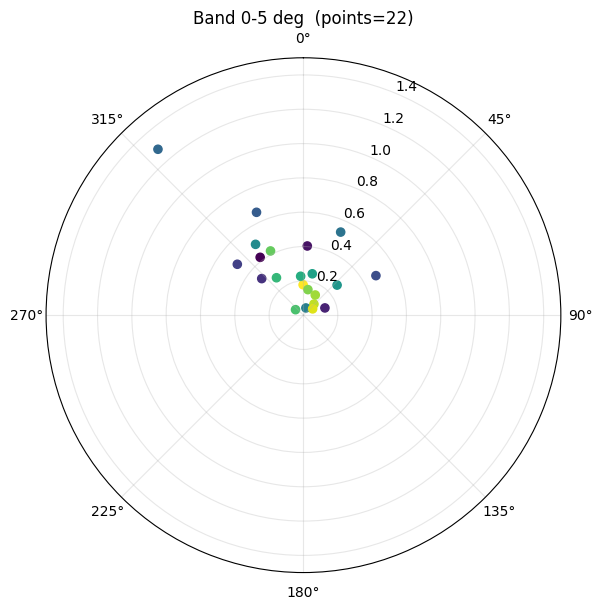

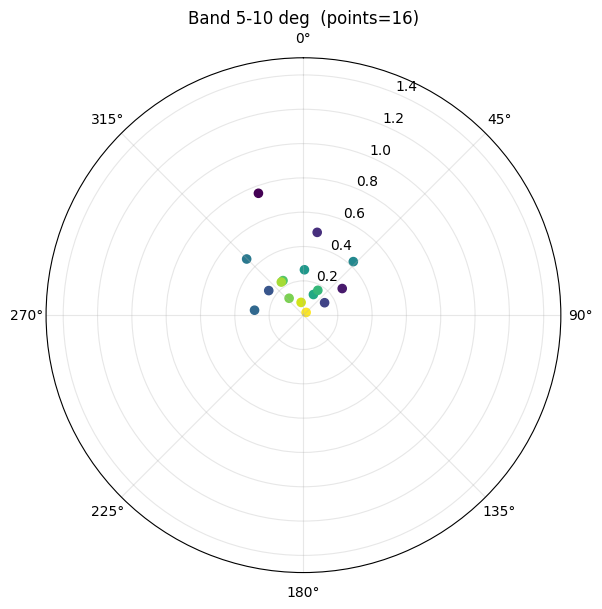

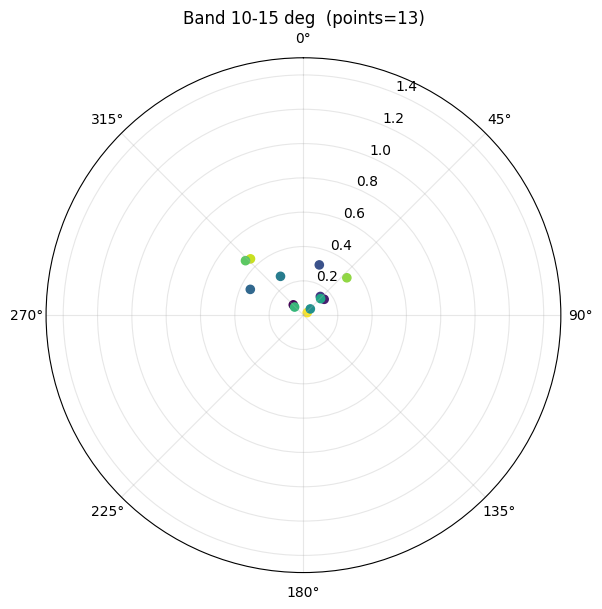

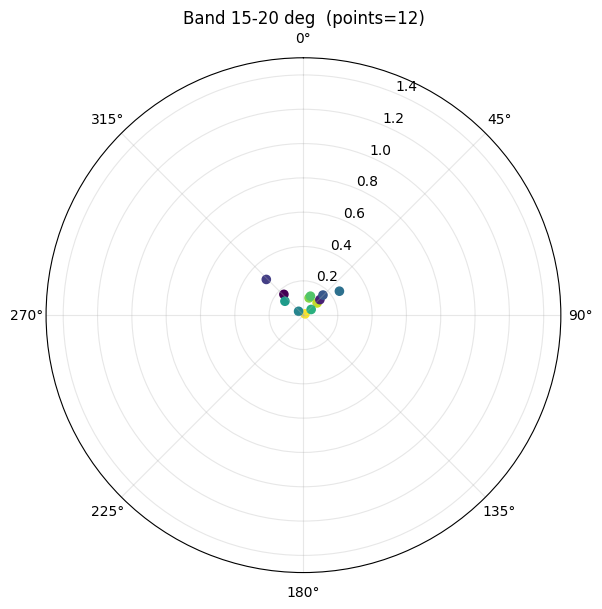

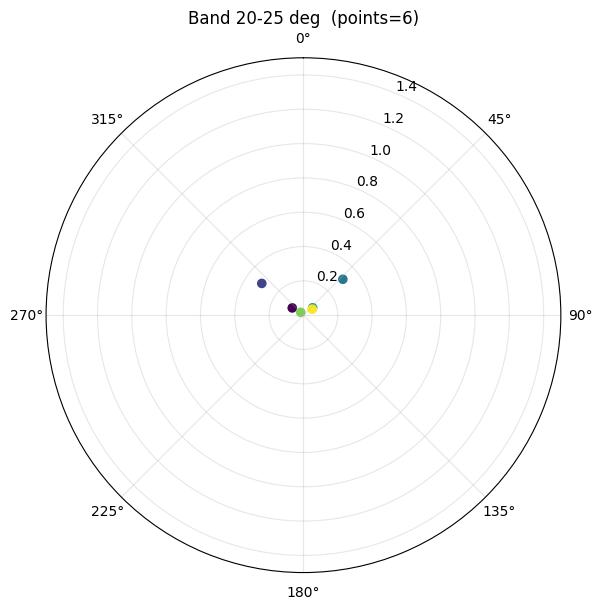

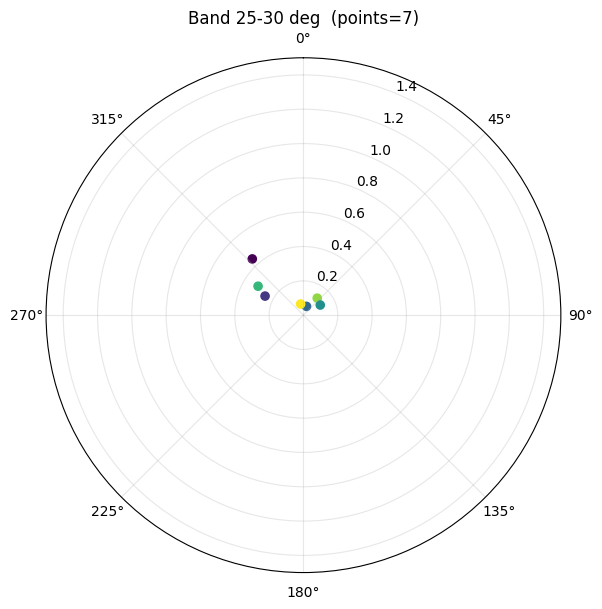

anisotropy fit: {'ok': True, 'reason': 'ok', 'model': 'interaction', 'az_major': 33.376421588215585, 'az_major2': 213.37642158821558, 'amp_logR_med': 0.08440316593590885, 'rmse_w': 0.2764280409198212, 'n': 2614, 'poly_deg_e': 3, 'poly_deg_az': 2, 'beta_e': array([ -0.72110708,   3.58784519, -25.85866491,  38.10911843]), 'B': array([ 0.28697825, -2.84038506,  5.39120175]), 'C': array([ 0.03954098, -0.33156582,  0.98917668])}
anisotropy bootstrap: {'ok': True, 'reason': 'ok', 'model': 'interaction', 'n_boot': 500, 'n_ok': 500, 'az_mean': 33.6170711853232, 'az_ci95_low': 4.7972489412465364, 'az_ci95_high': 62.34409134301308, 'amp_med': 0.08643188617937121, 'amp_ci95_low': 0.05484901888579802, 'amp_ci95_high': 0.11687808230583915}


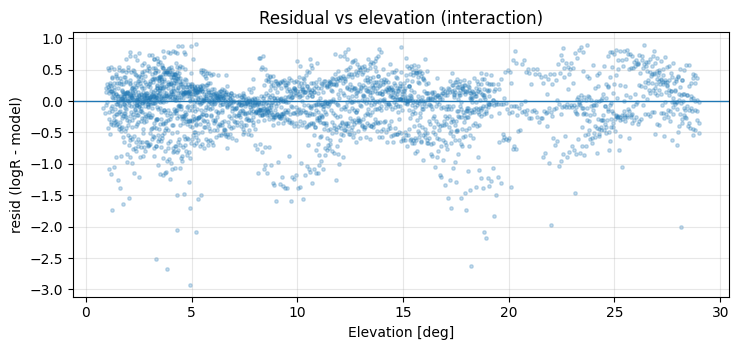

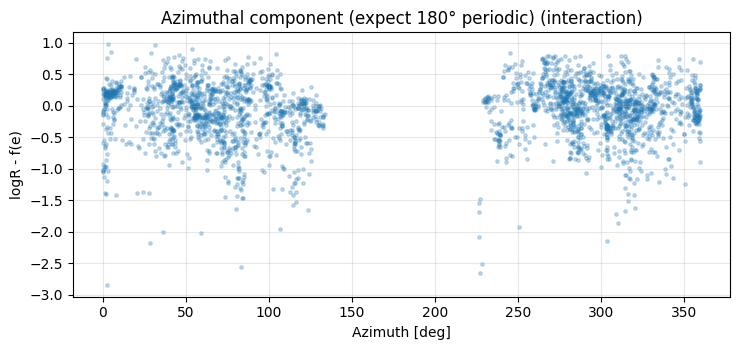

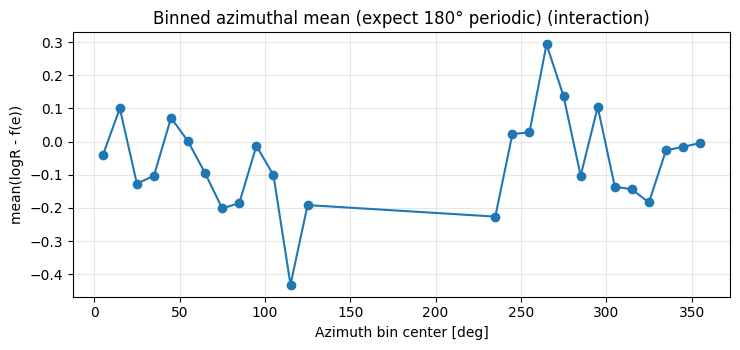

In [94]:
from __future__ import annotations

from dataclasses import dataclass, replace
from typing import Iterable, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

# =========================================================
# User config (このセルだけ触ればOK)
# =========================================================

MODE = "single"   # "single" or "range"

# --- single day ---
SINGLE_YEAR = 2024
SINGLE_DOY  = 244

# --- range mode (inclusive) ---
START_YEAR = 2024
START_DOY  = 240
END_YEAR   = 2025
END_DOY    = 93

OUT_CSV = None           # band楕円の出力
OUT_FIT_CSV = None       # anisotropy fit（range時）を保存したいなら

# --- anisotropy fit options ---
ANISO_MODEL = "interaction" # "simple" or "interaction" mode
ANISO_ENABLE = True
ANISO_POLY_DEG = 3
ANISO_N_BOOT = 500       # 重いなら 100〜300 に落とす
ANISO_SEED = 1

# single モードだけ診断プロット
ANISO_PLOT_DIAGNOSTICS_SINGLE = True

# =========================================================
# Config
# =========================================================

R_LIM_MAX = 1.5  # plotの見やすさ用（解析のフィルタとは別）


@dataclass(frozen=True)
class RunConfig:
    year: int = 2024
    station: str = "tgf3"
    doy: int = 240
    signal: str = "L1"
    az_range: tuple[float, float] = (225, 135)

    h0: float = 29.5
    h_grid: np.ndarray = np.linspace(0.5, 40.0, 396)
    N_EDGE_TRIM: int = 10

    # band power params
    COH_HALF_WIDTH: float = 5
    INC_H_MAX: float = 15

    # per-track time-series plots use this e-range (deg)
    E_MIN: float = 0.0
    E_MAX: float = 30.0
    MIN_POINTS: int = 5

    # band polar (deg)
    E_BANDS: tuple[tuple[float, float], ...] = ((0, 5), (5, 10), (10, 15), (15, 20), (20, 25), (25, 30))
    MIN_POINTS_BAND: int = 6

    MAX_PLOTS: int = 12  # 1dayモードで wavelet/scalogram を出す上限

    H_CAP: float = 35.0
    MAD_Z: float = 3.0
    MAD_GUARD: float = 3.0

    INCOH_MODE: str = "outside_coh"  # "outside_coh" or "low_h"

    # ratioスパイク対策（P_cohが小さいe点を落とす）
    PCOH_FLOOR_Q: float = 0.20
    PCOH_FLOOR_ABS: float = 0.0

    # 代表値（極座標/楕円入力用のr値自体）
    R_REP: str = "median"  # "median" or "p95"

    # ---------- 楕円推定用の自動フィルタ ----------
    ELL_R_MAX_TRUST: float = 1.0
    ELL_OUTLIER_METHOD: str = "madlog"    # "madlog" | "iqrlog" | "quantile"
    ELL_OUTLIER_Z: float = 3.0
    ELL_Q_LOW: float = 0.02
    ELL_Q_HIGH: float = 0.98

    # ---------- 楕円フィット設定 ----------
    ELL_MIN_POINTS: int = 6
    ELL_SCALE_Q: float = 0.80
    ELL_B_MIN_ABS: float = 0.15
    ELL_B_MIN_FRAC: float = 0.30
    ELL_AR_MAX: float = 4.0

    # ---------- 楕円：方位ビン集約（prominent cluster優先） ----------
    ELL_USE_AZ_BIN: bool = True
    ELL_AZ_BIN_DEG: float = 15.0
    ELL_AZ_BIN_MIN_COUNT: int = 2
    ELL_AZ_BIN_Q: float = 0.80
    ELL_AZ_BIN_WEIGHT_ALPHA: float = 1.0

    # 1dayモードで band polar を出すか
    PLOT_BAND_POLARS: bool = True

    # --- ridgeゲート：ピークがh0付近のeだけ ratio を有効にする ---
    RIDGE_GATE: bool = True
    RIDGE_GATE_WIDTH: float | None = None   # Noneなら COH_HALF_WIDTH を使う
    RIDGE_GATE_USE_DENOISED: bool = True    # P_dn で ridge を取る（推奨）


# =========================================================
# Basic utilities
# =========================================================

SIGNAL_COL_MAP = {
    "L1": "snr_L1",
    "L2": "snr_L2",
    "L5": "snr_L5",
    "L6": "snr_L6",
    "L7": "snr_L7",
    "L8": "snr_L8",
}


def normalize_angle_deg(angle: float) -> float:
    return float(np.mod(angle, 360.0))


def azimuth_in_range(az_deg: np.ndarray, az_min: float, az_max: float) -> np.ndarray:
    az = np.mod(np.asarray(az_deg, float), 360.0)
    amin = normalize_angle_deg(az_min)
    amax = normalize_angle_deg(az_max)
    if amin <= amax:
        return (az >= amin) & (az <= amax)
    else:
        return (az >= amin) | (az <= amax)


def add_direction_by_elev(df: pd.DataFrame, eps: float = 1e-3) -> pd.DataFrame:
    if df.empty:
        return df.assign(direction_flag=pd.Series(dtype=str))
    d = df.sort_values("sec_of_day").copy()
    de = d["elev_deg"].diff().to_numpy()
    if len(de) >= 2 and np.isnan(de[0]):
        de[0] = de[1]
    de = np.nan_to_num(de, nan=0.0)
    d["direction_flag"] = np.where(de > eps, "up", np.where(de < -eps, "down", "flat"))
    return d


def select_observations(
    snr_table: pd.DataFrame,
    *,
    doy: int | None = None,
    sat: int | None = None,
    signal: str = "L1",
    az_range: tuple[float, float] | None = None,
) -> tuple[pd.DataFrame, str]:
    if signal not in SIGNAL_COL_MAP:
        raise ValueError(f"unknown signal={signal}")
    sig_col = SIGNAL_COL_MAP[signal]
    if sig_col not in snr_table.columns:
        raise KeyError(f"{sig_col} not in snr_table.columns")

    df = snr_table
    if doy is not None:
        df = df[df["doy"] == doy]
    if sat is not None:
        df = df[df["sat"] == sat]
    if az_range is not None:
        m = azimuth_in_range(df["az_deg"].to_numpy(), az_range[0], az_range[1])
        df = df[m]

    df = df.sort_values("elev_deg").reset_index(drop=True)
    return df, sig_col


def circular_mean_deg(angles_deg: np.ndarray) -> float:
    a = np.asarray(angles_deg, float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return np.nan
    r = np.deg2rad(a)
    x = np.cos(r).mean()
    y = np.sin(r).mean()
    if x == 0 and y == 0:
        return np.nan
    return float(np.mod(np.rad2deg(np.arctan2(y, x)), 360.0))


def interp_circular_deg(x: np.ndarray, ang_deg: np.ndarray, x_new: np.ndarray) -> np.ndarray:
    x = np.asarray(x, float)
    ang = np.asarray(ang_deg, float)
    m = np.isfinite(x) & np.isfinite(ang)
    if np.sum(m) < 2:
        return np.full_like(x_new, np.nan, dtype=float)
    xr = x[m]
    ar = np.deg2rad(ang[m])
    cx = np.cos(ar)
    sy = np.sin(ar)
    cx_i = np.interp(x_new, xr, cx)
    sy_i = np.interp(x_new, xr, sy)
    ang_i = np.rad2deg(np.arctan2(sy_i, cx_i))
    return np.mod(ang_i, 360.0)


def percentile_rank_0_1(values: np.ndarray) -> np.ndarray:
    v = np.asarray(values, float)
    out = np.full_like(v, np.nan, dtype=float)
    m = np.isfinite(v)
    if np.sum(m) == 0:
        return out
    out[m] = pd.Series(v[m]).rank(method="average").to_numpy() / np.sum(m)
    return out


# =========================================================
# Wavelet -> P(e,h) + az aligned
# =========================================================

def detrend_poly(x: np.ndarray, y: np.ndarray, order: int = 2) -> np.ndarray:
    coef = np.polyfit(x, y, order)
    trend = np.polyval(coef, x)
    return y - trend


def compute_wavelet_power_e_h_with_az(
    elev_deg: np.ndarray,
    snr_series: np.ndarray,
    az_deg: np.ndarray,
    h_grid: np.ndarray,
    *,
    wavelength_m: float = 0.190293672798365,
    wavelet_name: str = "cmor10.0-5.0",
    detrend_order: int = 2,
):
    elev_deg = np.asarray(elev_deg, float)
    snr_series = np.asarray(snr_series, float)
    az_deg = np.asarray(az_deg, float)
    h_grid = np.asarray(h_grid, float)

    m = np.isfinite(elev_deg) & np.isfinite(snr_series) & np.isfinite(az_deg)
    elev_deg = elev_deg[m]
    snr_series = snr_series[m]
    az_deg = az_deg[m]
    if elev_deg.size < 30:
        raise ValueError("not enough points for wavelet")

    x = np.sin(np.deg2rad(elev_deg))
    order = np.argsort(x)
    x = x[order]
    y = snr_series[order]
    az = az_deg[order]

    N = len(x)
    x_uniform = np.linspace(x[0], x[-1], N)
    y_uniform = np.interp(x_uniform, x, y)
    az_uniform = interp_circular_deg(x, az, x_uniform)

    y_detr = detrend_poly(x_uniform, y_uniform, order=detrend_order)

    dt = x_uniform[1] - x_uniform[0]
    wavelet = pywt.ContinuousWavelet(wavelet_name)
    f_c = pywt.central_frequency(wavelet)

    scales = np.zeros_like(h_grid, dtype=float)
    valid = h_grid > 0
    f_x = np.zeros_like(h_grid, dtype=float)
    f_x[valid] = 2.0 * h_grid[valid] / wavelength_m
    scales[valid] = f_c / (f_x[valid] * dt)

    valid_idx = np.where(valid & np.isfinite(scales) & (scales > 0))[0]
    if valid_idx.size == 0:
        raise ValueError("no valid scales")

    scales_valid = scales[valid_idx]
    coeffs, _ = pywt.cwt(y_detr, scales_valid, wavelet, sampling_period=dt)
    power_valid = (np.abs(coeffs) ** 2) / np.abs(scales_valid)[:, None]  # (Nh_valid, N)

    P = np.zeros((N, len(h_grid)), dtype=float)
    for j, h_idx in enumerate(valid_idx):
        P[:, h_idx] = power_valid[j, :]

    e_grid = np.rad2deg(np.arcsin(x_uniform))
    return e_grid, az_uniform, h_grid, P


# =========================================================
# coh/inc power + ratio
# =========================================================

def denoise_power_mad_per_e(
    P_eh: np.ndarray,
    h_grid: np.ndarray,
    *,
    h0: float,
    coh_half_width: float,
    h_cap: float,
    z: float = 3.0,
    guard: float = 3.0,
) -> tuple[np.ndarray, np.ndarray]:
    P = np.asarray(P_eh, float)
    h = np.asarray(h_grid, float)

    Ne, _ = P.shape
    P_dn = np.zeros_like(P, dtype=float)
    thr = np.full(Ne, np.nan, dtype=float)

    mh = (h >= 0.0) & (h <= h_cap)
    m_noise = mh & ~((h >= (h0 - coh_half_width - guard)) & (h <= (h0 + coh_half_width + guard)))

    for i in range(Ne):
        v = P[i, m_noise]
        v = v[np.isfinite(v)]
        if v.size < 10:
            v = P[i, mh]
            v = v[np.isfinite(v)]
        if v.size < 10:
            thr[i] = 0.0
        else:
            med = float(np.median(v))
            mad = float(np.median(np.abs(v - med)))
            sigma = 1.4826 * mad
            thr[i] = med + z * sigma

        P_dn[i, mh] = np.maximum(P[i, mh] - thr[i], 0.0)

    return P_dn, thr


def band_integral_per_e(P_eh: np.ndarray, h_grid: np.ndarray, h_min: float, h_max: float) -> np.ndarray:
    P = np.asarray(P_eh, float)
    h = np.asarray(h_grid, float)
    m = (h >= h_min) & (h <= h_max)
    if not np.any(m):
        raise ValueError(f"band empty: [{h_min},{h_max}] not in h_grid")
    return np.nansum(P[:, m], axis=1)


def compute_coh_inc_power_per_e(
    e_deg: np.ndarray,
    P_eh: np.ndarray,
    h_grid: np.ndarray,
    *,
    h0: float,
    coh_half_width: float = 5.0,
    h_cap: float = 35.0,
    mad_z: float = 3.0,
    mad_guard: float = 3.0,
    incoh_mode: str = "outside_coh",
    inc_h_max: float = 15.0,
    pcoh_floor_q: float = 0.20,
    pcoh_floor_abs: float = 0.0,
    eps: float = 1e-18,
    ridge_gate: bool = False,
    ridge_gate_width: float | None = None,
    ridge_gate_use_denoised: bool = True,
) -> dict[str, Any]:
    e = np.asarray(e_deg, float)
    P = np.asarray(P_eh, float)
    h = np.asarray(h_grid, float)

    P_dn, thr = denoise_power_mad_per_e(
        P, h,
        h0=h0,
        coh_half_width=coh_half_width,
        h_cap=h_cap,
        z=mad_z,
        guard=mad_guard,
    )

    # ridge gate: peak height must be near h0
    ridge_h = np.full_like(e, np.nan, dtype=float)
    ridge_ok = np.ones_like(e, dtype=bool)

    if ridge_gate:
        gate_w = float(coh_half_width if ridge_gate_width is None else ridge_gate_width)
        P_for_ridge = P_dn if ridge_gate_use_denoised else P
        mh_ridge = (h >= 0.0) & (h <= h_cap)

        for i in range(P_for_ridge.shape[0]):
            row = P_for_ridge[i, mh_ridge]
            if row.size == 0:
                ridge_ok[i] = False
                continue
            mx = np.nanmax(row)
            if (not np.isfinite(mx)) or (mx <= 0.0):
                ridge_ok[i] = False
                continue
            j = int(np.nanargmax(row))
            ridge_h[i] = float(h[mh_ridge][j])
            ridge_ok[i] = np.isfinite(ridge_h[i]) and (abs(ridge_h[i] - h0) <= gate_w)

    P_coh = band_integral_per_e(P_dn, h, h0 - coh_half_width, h0 + coh_half_width)

    if incoh_mode == "low_h":
        P_inc = band_integral_per_e(P_dn, h, 0.0, inc_h_max)
        P_total = np.nan * np.ones_like(P_coh)
    elif incoh_mode == "outside_coh":
        P_total = band_integral_per_e(P_dn, h, 0.0, h_cap)
        P_inc = np.maximum(P_total - P_coh, 0.0)
    else:
        raise ValueError("incoh_mode must be 'outside_coh' or 'low_h'")

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = P_inc / (P_coh + eps)
    ratio = ratio.astype(float)
    ratio[~np.isfinite(ratio)] = np.nan

    if ridge_gate:
        P_coh = P_coh.copy()
        P_inc = P_inc.copy()
        ratio = ratio.copy()
        P_coh[~ridge_ok] = np.nan
        P_inc[~ridge_ok] = np.nan
        ratio[~ridge_ok] = np.nan

    pc = P_coh[np.isfinite(P_coh)]
    if pc.size >= 10:
        q_floor = float(np.nanquantile(pc, pcoh_floor_q))
        floor = max(q_floor, float(pcoh_floor_abs))
        bad = ~np.isfinite(P_coh) | (P_coh <= floor)

        P_coh = P_coh.copy()
        P_inc = P_inc.copy()
        ratio = ratio.copy()
        P_coh[bad] = np.nan
        P_inc[bad] = np.nan
        ratio[bad] = np.nan
    else:
        floor = np.nan
        bad = np.zeros_like(P_coh, dtype=bool)

    return dict(
        e=e,
        P_coh=P_coh,
        P_inc=P_inc,
        ratio=ratio,
        P_total=P_total if incoh_mode == "outside_coh" else np.nan,
        thr=thr,
        pcoh_floor=floor,
        bad_mask=bad,
        ridge_h=ridge_h,
        ridge_ok=ridge_ok,
    )


# =========================================================
# Summaries
# =========================================================

def summarize_track_ratio_and_az(
    e_deg: np.ndarray,
    az_deg: np.ndarray,
    P_coh: np.ndarray,
    P_inc: np.ndarray,
    ratio: np.ndarray,
    *,
    e_min: float,
    e_max: float,
    min_points: int,
    use_log10_for_var: bool = True,
):
    e = np.asarray(e_deg, float)
    az = np.asarray(az_deg, float)
    Pc = np.asarray(P_coh, float)
    Pi = np.asarray(P_inc, float)
    R = np.asarray(ratio, float)

    m = (
        np.isfinite(e) & (e >= e_min) & (e <= e_max)
        & np.isfinite(az)
        & np.isfinite(Pc) & np.isfinite(Pi)
        & np.isfinite(R) & (R > 0)
    )
    n = int(np.sum(m))
    if n < min_points:
        return np.nan, np.nan, np.nan, np.nan, np.nan, n

    coh_rep = float(np.nanmedian(Pc[m]))
    inc_rep = float(np.nanmedian(Pi[m]))
    ratio_rep = float(np.nanmedian(R[m]))
    az_rep = circular_mean_deg(az[m])

    x = np.log10(R[m]) if use_log10_for_var else R[m]
    ratio_var = float(np.nanvar(x, ddof=1)) if n >= 2 else np.nan
    return coh_rep, inc_rep, ratio_rep, ratio_var, az_rep, n


def summarize_band_ratio(
    e_deg: np.ndarray,
    az_deg: np.ndarray,
    ratio: np.ndarray,
    *,
    e_min: float,
    e_max: float,
    min_points: int,
    use_log10_for_var: bool = True,
    rep: str = "median",
):
    e = np.asarray(e_deg, float)
    az = np.asarray(az_deg, float)
    R = np.asarray(ratio, float)

    m = (
        np.isfinite(e) & (e >= e_min) & (e <= e_max)
        & np.isfinite(az)
        & np.isfinite(R) & (R > 0)
    )
    n = int(np.sum(m))
    if n < min_points:
        return np.nan, np.nan, np.nan, n

    if rep == "median":
        ratio_rep = float(np.nanmedian(R[m]))
    elif rep == "p95":
        ratio_rep = float(np.nanpercentile(R[m], 95))
    else:
        raise ValueError("rep must be 'median' or 'p95'")

    az_rep = circular_mean_deg(az[m])

    x = np.log10(R[m]) if use_log10_for_var else R[m]
    ratio_var = float(np.nanvar(x, ddof=1)) if n >= 2 else np.nan
    return ratio_rep, ratio_var, az_rep, n


# =========================================================
# Ellipse estimation (band別 az)
# =========================================================

def select_points_for_ellipse(
    az_deg: np.ndarray,
    r: np.ndarray,
    *,
    r_max_trust: float = 2.0,
    method: str = "madlog",
    z: float = 3.0,
    q_low: float = 0.02,
    q_high: float = 0.98,
    min_points: int = 6,
):
    az = np.asarray(az_deg, float)
    rr = np.asarray(r, float)

    m = np.isfinite(az) & np.isfinite(rr) & (rr > 0) & (rr <= float(r_max_trust))
    if int(np.sum(m)) < min_points:
        return m, {"n_keep": int(np.sum(m)), "reason": "too_few_after_cap"}

    r0 = rr[m]

    if method == "madlog":
        x = np.log10(np.maximum(r0, 1e-12))
        med = float(np.nanmedian(x))
        mad = float(np.nanmedian(np.abs(x - med)))
        sig = 1.4826 * mad
        if (not np.isfinite(sig)) or sig <= 0:
            keep_local = np.ones_like(r0, dtype=bool)
        else:
            keep_local = np.abs(x - med) <= float(z) * sig

    elif method == "iqrlog":
        x = np.log10(np.maximum(r0, 1e-12))
        q1 = float(np.nanpercentile(x, 25))
        q3 = float(np.nanpercentile(x, 75))
        iqr = q3 - q1
        if (not np.isfinite(iqr)) or iqr <= 0:
            keep_local = np.ones_like(r0, dtype=bool)
        else:
            lo = q1 - 1.5 * iqr
            hi = q3 + 1.5 * iqr
            keep_local = (x >= lo) & (x <= hi)

    elif method == "quantile":
        lo = float(np.nanquantile(r0, q_low))
        hi = float(np.nanquantile(r0, q_high))
        keep_local = (r0 >= lo) & (r0 <= hi)

    else:
        raise ValueError("method must be 'madlog', 'iqrlog', or 'quantile'")

    idx = np.where(m)[0]
    m2 = m.copy()
    m2[idx[~keep_local]] = False

    info = dict(
        n_in=int(len(rr)),
        n_after_cap=int(np.sum(m)),
        n_keep=int(np.sum(m2)),
        r_max_trust=float(r_max_trust),
        method=str(method),
    )
    return m2, info


def az_bin_quantile_points(
    az_deg: np.ndarray,
    r: np.ndarray,
    *,
    bin_deg: float = 15.0,
    q: float = 0.80,
    min_count: int = 2,
):
    az = np.mod(np.asarray(az_deg, float), 360.0)
    rr = np.asarray(r, float)
    m = np.isfinite(az) & np.isfinite(rr) & (rr > 0)
    az = az[m]
    rr = rr[m]
    if az.size == 0:
        return np.array([]), np.array([]), np.array([])

    nb = int(np.ceil(360.0 / float(bin_deg)))
    edges = np.linspace(0.0, 360.0, nb + 1)

    az_out, r_out, c_out = [], [], []
    for i in range(nb):
        a0, a1 = edges[i], edges[i + 1]
        mm = (az >= a0) & (az < a1) if i < nb - 1 else (az >= a0) & (az <= a1)
        if int(np.sum(mm)) < int(min_count):
            continue
        r_rep = float(np.nanquantile(rr[mm], q))
        if not np.isfinite(r_rep) or r_rep <= 0:
            continue
        az_rep = float((a0 + a1) * 0.5) % 360.0
        az_out.append(az_rep)
        r_out.append(r_rep)
        c_out.append(int(np.sum(mm)))

    return np.array(az_out, float), np.array(r_out, float), np.array(c_out, float)


def fit_origin_centered_ellipse_polar(
    az_deg: np.ndarray,
    r: np.ndarray,
    *,
    w: np.ndarray | None = None,
    min_points: int = 6,
    b_min_abs: float = 0.15,
    b_min_frac: float = 0.30,
    ar_max: float = 4.0,
):
    az = np.asarray(az_deg, float)
    rr = np.asarray(r, float)
    m = np.isfinite(az) & np.isfinite(rr) & (rr > 0)
    az = az[m]
    rr = rr[m]
    if az.size < min_points:
        return None

    th = np.deg2rad(az)
    y = 1.0 / (rr ** 2)
    X = np.column_stack([np.ones_like(th), np.cos(2 * th), np.sin(2 * th)])

    if w is None:
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    else:
        ww = np.asarray(w, float)[m]
        ww = np.where(np.isfinite(ww) & (ww > 0), ww, 0.0)
        s = np.sqrt(ww)
        beta, *_ = np.linalg.lstsq(X * s[:, None], y * s, rcond=None)

    A, B, C = (float(beta[0]), float(beta[1]), float(beta[2]))
    Q = np.array([[A + B, C],
                  [C,     A - B]], dtype=float)

    evals, evecs = np.linalg.eigh(Q)
    evals = np.maximum(evals, 1e-12)

    idx = np.argsort(evals)
    lam_small = evals[idx[0]]
    lam_large = evals[idx[1]]
    v_long = evecs[:, idx[0]]

    a = 1.0 / np.sqrt(lam_small)  # major
    b = 1.0 / np.sqrt(lam_large)  # minor

    b_floor = max(b_min_abs, b_min_frac * float(np.nanmedian(rr)))
    b = max(b, b_floor)

    if a / b > ar_max:
        b = a / ar_max
        b = max(b, b_floor)

    phi = float(np.mod(np.rad2deg(np.arctan2(v_long[1], v_long[0])), 180.0))
    return {"a": float(a), "b": float(b), "phi_deg": phi}


def ellipse_r_theta(theta_deg: np.ndarray, a: float, b: float, phi_deg: float) -> np.ndarray:
    th = np.deg2rad(np.asarray(theta_deg, float))
    ph = np.deg2rad(float(phi_deg))
    d = th - ph
    denom = np.sqrt((b * np.cos(d)) ** 2 + (a * np.sin(d)) ** 2)
    return (a * b) / np.maximum(denom, 1e-12)


def estimate_band_major_axis(az_deg: np.ndarray, r: np.ndarray, *, cfg: RunConfig) -> dict[str, Any]:
    az = np.asarray(az_deg, float)
    rr = np.asarray(r, float)

    m_sel, sel_info = select_points_for_ellipse(
        az, rr,
        r_max_trust=cfg.ELL_R_MAX_TRUST,
        method=cfg.ELL_OUTLIER_METHOD,
        z=cfg.ELL_OUTLIER_Z,
        q_low=cfg.ELL_Q_LOW,
        q_high=cfg.ELL_Q_HIGH,
        min_points=cfg.ELL_MIN_POINTS,
    )
    az0 = az[m_sel]
    r0  = rr[m_sel]
    if az0.size < cfg.ELL_MIN_POINTS:
        return dict(
            ok=False, reason="too_few_points",
            az_major=np.nan, az_major2=np.nan,
            a=np.nan, b=np.nan, axis_ratio=np.nan, phi_deg=np.nan,
            n_fit=0, n_all=int(len(r0)),
            **{f"sel_{k}": v for k, v in sel_info.items()},
        )

    if cfg.ELL_USE_AZ_BIN:
        az_fit, r_fit, cnt = az_bin_quantile_points(
            az0, r0,
            bin_deg=cfg.ELL_AZ_BIN_DEG,
            q=cfg.ELL_AZ_BIN_Q,
            min_count=cfg.ELL_AZ_BIN_MIN_COUNT,
        )
        w_use = np.power(cnt, float(cfg.ELL_AZ_BIN_WEIGHT_ALPHA)) if cnt.size else None
    else:
        az_fit, r_fit = az0, r0
        w_use = None

    if r_fit.size < cfg.ELL_MIN_POINTS:
        return dict(
            ok=False, reason="too_few_after_azbin",
            az_major=np.nan, az_major2=np.nan,
            a=np.nan, b=np.nan, axis_ratio=np.nan, phi_deg=np.nan,
            n_fit=int(len(r_fit)), n_all=int(len(r0)),
            **{f"sel_{k}": v for k, v in sel_info.items()},
        )

    ell = fit_origin_centered_ellipse_polar(
        az_fit, r_fit,
        w=w_use,
        min_points=cfg.ELL_MIN_POINTS,
        b_min_abs=cfg.ELL_B_MIN_ABS,
        b_min_frac=cfg.ELL_B_MIN_FRAC,
        ar_max=cfg.ELL_AR_MAX,
    )
    if ell is None:
        return dict(
            ok=False, reason="fit_failed",
            az_major=np.nan, az_major2=np.nan,
            a=np.nan, b=np.nan, axis_ratio=np.nan, phi_deg=np.nan,
            n_fit=int(len(r_fit)), n_all=int(len(r0)),
            **{f"sel_{k}": v for k, v in sel_info.items()},
        )

    if 0.0 < cfg.ELL_SCALE_Q < 1.0:
        r_hat = ellipse_r_theta(az_fit, ell["a"], ell["b"], ell["phi_deg"])
        num = np.nanquantile(r_fit, cfg.ELL_SCALE_Q)
        den = np.nanquantile(r_hat, cfg.ELL_SCALE_Q)
        if np.isfinite(num) and np.isfinite(den) and den > 0:
            s = float(num / den)
            ell["a"] *= s
            ell["b"] *= s

    th_grid_deg = np.linspace(0.0, 360.0, 721)
    r_ell = ellipse_r_theta(th_grid_deg, ell["a"], ell["b"], ell["phi_deg"])
    i_max = int(np.nanargmax(r_ell))
    az_major = float(th_grid_deg[i_max]) % 360.0
    az_major2 = (az_major + 180.0) % 360.0

    a = float(ell["a"])
    b = float(ell["b"])
    return dict(
        ok=True, reason="ok",
        az_major=az_major, az_major2=az_major2,
        a=a, b=b,
        axis_ratio=float(a / max(b, 1e-12)),
        phi_deg=float(ell["phi_deg"]),
        n_fit=int(len(r_fit)),
        n_all=int(len(r0)),
        **{f"sel_{k}": v for k, v in sel_info.items()},
    )


# =========================================================
# Anisotropy fit (switchable) + CI + diagnostics
# =========================================================

def _fit_aniso_simple(df_points: pd.DataFrame, *, poly_deg: int = 3) -> dict[str, Any]:
    """
    y = f(e) + B cos(2θ) + C sin(2θ)
    f(e)=poly(sin(e)) of degree poly_deg
    """
    if df_points.empty:
        return dict(ok=False, reason="no_points", model="simple")

    e = df_points["e"].to_numpy(float)
    th = np.deg2rad(df_points["az"].to_numpy(float))
    y = df_points["logR"].to_numpy(float)

    w = df_points["w"].to_numpy(float)
    w = np.where(np.isfinite(w) & (w > 0), w, 0.0)

    m = np.isfinite(e) & np.isfinite(th) & np.isfinite(y) & (w > 0)
    if int(m.sum()) < 30:
        return dict(ok=False, reason="too_few_points", n=int(m.sum()), model="simple")

    e = e[m]; th = th[m]; y = y[m]; w = w[m]
    s = np.sin(np.deg2rad(e))

    Xe = np.column_stack([s**k for k in range(int(poly_deg) + 1)])
    Xaz = np.column_stack([np.cos(2*th), np.sin(2*th)])
    X = np.column_stack([Xe, Xaz])

    sw = np.sqrt(w)
    beta, *_ = np.linalg.lstsq(X * sw[:, None], y * sw, rcond=None)

    beta_e = beta[:int(poly_deg) + 1].copy()
    B = float(beta[-2])
    C = float(beta[-1])

    # major axis az: 0.5*atan2(C,B)  (180-deg periodic)
    phi = 0.5 * np.arctan2(C, B)
    az_major = float(np.mod(np.rad2deg(phi), 180.0))
    az_major2 = (az_major + 180.0) % 360.0
    amp = float(np.hypot(B, C))

    y_hat = (X @ beta)
    resid = y - y_hat
    rmse_w = float(np.sqrt(np.sum(w * resid**2) / np.sum(w)))

    return dict(
        ok=True, reason="ok", model="simple",
        az_major=az_major, az_major2=az_major2,
        amp_logR=amp,
        B=B, C=C,
        beta_e=beta_e,
        rmse_w=rmse_w,
        n=int(len(y)),
        poly_deg=int(poly_deg),
    )


def _fit_aniso_interaction(
    df_points: pd.DataFrame,
    *,
    poly_deg_e: int = 3,
    poly_deg_az: int = 2,
) -> dict[str, Any]:
    """
    y = f(e) + B(e)cos(2θ) + C(e)sin(2θ)
    f(e)  = Σ a_k s^k
    B(e)  = Σ b_k s^k
    C(e)  = Σ c_k s^k
    where s=sin(e)
    """
    if df_points.empty:
        return dict(ok=False, reason="no_points", model="interaction")

    e = df_points["e"].to_numpy(float)
    th = np.deg2rad(df_points["az"].to_numpy(float))
    y = df_points["logR"].to_numpy(float)

    w = df_points["w"].to_numpy(float)
    w = np.where(np.isfinite(w) & (w > 0), w, 0.0)

    m = np.isfinite(e) & np.isfinite(th) & np.isfinite(y) & (w > 0)
    if int(m.sum()) < 50:
        return dict(ok=False, reason="too_few_points", n=int(m.sum()), model="interaction")

    e = e[m]; th = th[m]; y = y[m]; w = w[m]
    s = np.sin(np.deg2rad(e))

    poly_deg_e = int(poly_deg_e)
    poly_deg_az = int(poly_deg_az)

    Xe = np.column_stack([s**k for k in range(poly_deg_e + 1)])   # f(e)
    G  = np.column_stack([s**k for k in range(poly_deg_az + 1)])  # B(e),C(e)

    c2 = np.cos(2*th)
    s2 = np.sin(2*th)

    Xb = G * c2[:, None]
    Xc = G * s2[:, None]
    X = np.column_stack([Xe, Xb, Xc])

    sw = np.sqrt(w)
    beta, *_ = np.linalg.lstsq(X * sw[:, None], y * sw, rcond=None)

    a = beta[: (poly_deg_e + 1)]
    Bk = beta[(poly_deg_e + 1) : (poly_deg_e + 1) + (poly_deg_az + 1)]
    Ck = beta[(poly_deg_e + 1) + (poly_deg_az + 1) :]

    # Per-point B(e),C(e)
    Be = (G @ Bk)
    Ce = (G @ Ck)
    amp_e = np.hypot(Be, Ce)

    # 方位：180周期 → exp(i*2*az) の平均（= exp(i*atan2(C,B))）
    # ※ここで 2倍しすぎないのが重要
    z = (amp_e * w) * np.exp(1j * np.arctan2(Ce, Be))  # phase = 2*az
    mean_phi2 = np.angle(np.mean(z))
    az_major = (np.rad2deg(mean_phi2) / 2.0) % 180.0
    az_major2 = (az_major + 180.0) % 360.0

    yhat = X @ beta
    resid = y - yhat
    rmse_w = float(np.sqrt(np.sum(w * resid**2) / np.sum(w)))

    amp_med = float(np.nanmedian(amp_e))

    return dict(
        ok=True, reason="ok", model="interaction",
        az_major=float(az_major), az_major2=float(az_major2),
        amp_logR_med=amp_med,
        rmse_w=rmse_w,
        n=int(len(y)),
        poly_deg_e=poly_deg_e,
        poly_deg_az=poly_deg_az,
        beta_e=a, B=Bk, C=Ck,
    )


def fit_anisotropy_all_e(
    df_points: pd.DataFrame,
    *,
    model: str = "simple",     # "simple" | "interaction"
    # --- legacy compat ---
    poly_deg: int | None = None,
    # --- interaction params ---
    poly_deg_e: int = 3,
    poly_deg_az: int = 2,
) -> dict[str, Any]:
    """
    Switchable anisotropy fit.
    - model="simple": uses poly_deg (or poly_deg_e if poly_deg is None)
    - model="interaction": uses poly_deg_e, poly_deg_az
    Also accepts legacy poly_deg keyword to avoid breaking old calls.
    """
    if model == "simple":
        deg = int(poly_deg_e if poly_deg is None else poly_deg)
        return _fit_aniso_simple(df_points, poly_deg=deg)

    if model == "interaction":
        # poly_deg が渡ってきたら「f(e)の次数」として採用（互換）
        deg_e = int(poly_deg_e if poly_deg is None else poly_deg)
        return _fit_aniso_interaction(df_points, poly_deg_e=deg_e, poly_deg_az=int(poly_deg_az))

    return dict(ok=False, reason=f"unknown model={model}", model=str(model))


def bootstrap_anisotropy_ci(
    df_points: pd.DataFrame,
    *,
    model: str = "simple",
    poly_deg: int | None = None,
    poly_deg_e: int = 3,
    poly_deg_az: int = 2,
    n_boot: int = 500,
    seed: int = 0,
) -> dict[str, Any]:
    if df_points.empty:
        return dict(ok=False, reason="no_points", model=model)

    rng = np.random.default_rng(seed)
    az_list: list[float] = []
    amp_list: list[float] = []

    n = len(df_points)
    for _ in range(int(n_boot)):
        rs = int(rng.integers(0, 2**31 - 1))
        samp = df_points.sample(n=n, replace=True, random_state=rs)

        est = fit_anisotropy_all_e(
            samp,
            model=model,
            poly_deg=poly_deg,
            poly_deg_e=poly_deg_e,
            poly_deg_az=poly_deg_az,
        )
        if not est.get("ok", False):
            continue

        if np.isfinite(est.get("az_major", np.nan)):
            az_list.append(float(est["az_major"]))

        # amp のキーがモデルで違う
        if model == "simple":
            amp_key = "amp_logR"
        else:
            amp_key = "amp_logR_med"

        if np.isfinite(est.get(amp_key, np.nan)):
            amp_list.append(float(est[amp_key]))

    az = np.asarray(az_list, float)
    amp = np.asarray(amp_list, float)

    if az.size < max(30, int(n_boot) // 5):
        return dict(ok=False, reason="too_few_successful_boot", n_ok=int(az.size), n_boot=int(n_boot), model=model)

    phi2 = np.deg2rad(2.0 * az)
    mean_phi2 = np.angle(np.mean(np.exp(1j * phi2)))
    mean_az = (np.rad2deg(mean_phi2) / 2.0) % 180.0

    dphi2 = np.angle(np.exp(1j * (phi2 - mean_phi2)))
    lo, hi = np.percentile(dphi2, [2.5, 97.5])
    ci_phi2 = mean_phi2 + np.array([lo, hi])
    ci_az = (np.rad2deg(ci_phi2) / 2.0) % 180.0

    return dict(
        ok=True, reason="ok", model=model,
        n_boot=int(n_boot), n_ok=int(az.size),
        az_mean=float(mean_az),
        az_ci95_low=float(ci_az[0]),
        az_ci95_high=float(ci_az[1]),
        amp_med=float(np.nanmedian(amp)) if amp.size else np.nan,
        amp_ci95_low=float(np.nanpercentile(amp, 2.5)) if amp.size else np.nan,
        amp_ci95_high=float(np.nanpercentile(amp, 97.5)) if amp.size else np.nan,
    )


def plot_anisotropy_diagnostics(df_points: pd.DataFrame, fit: dict[str, Any]) -> None:
    if df_points.empty or (not fit.get("ok", False)):
        print("no diagnostics (no points or fit failed)")
        return

    model = fit.get("model", "simple")

    e = df_points["e"].to_numpy(float)
    th = np.deg2rad(df_points["az"].to_numpy(float))
    y = df_points["logR"].to_numpy(float)
    s = np.sin(np.deg2rad(e))

    if model == "simple":
        poly_deg = int(fit["poly_deg"])
        beta_e = np.asarray(fit["beta_e"], float)
        B = float(fit["B"]); C = float(fit["C"])

        f = np.zeros_like(s)
        for k in range(poly_deg + 1):
            f += beta_e[k] * (s ** k)

        y_hat = f + B*np.cos(2*th) + C*np.sin(2*th)

    else:
        poly_deg_e = int(fit["poly_deg_e"])
        poly_deg_az = int(fit["poly_deg_az"])
        a = np.asarray(fit["beta_e"], float)
        Bk = np.asarray(fit["B"], float)
        Ck = np.asarray(fit["C"], float)

        Xe = np.column_stack([s**k for k in range(poly_deg_e + 1)])
        G  = np.column_stack([s**k for k in range(poly_deg_az + 1)])
        Be = G @ Bk
        Ce = G @ Ck
        f = Xe @ a
        y_hat = f + Be*np.cos(2*th) + Ce*np.sin(2*th)

    resid = y - y_hat

    plt.figure(figsize=(7.5, 3.6))
    plt.scatter(e, resid, s=6, alpha=0.25)
    plt.axhline(0, lw=1)
    plt.xlabel("Elevation [deg]")
    plt.ylabel("resid (logR - model)")
    plt.title(f"Residual vs elevation ({model})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    y_az = y - f
    az_deg = (np.rad2deg(th) % 360.0)

    plt.figure(figsize=(7.5, 3.6))
    plt.scatter(az_deg, y_az, s=6, alpha=0.25)
    plt.xlabel("Azimuth [deg]")
    plt.ylabel("logR - f(e)")
    plt.title(f"Azimuthal component (expect 180° periodic) ({model})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    bin_deg = 10.0
    bins = np.arange(0.0, 360.0 + bin_deg, bin_deg)
    idx = np.digitize(az_deg, bins) - 1

    az_c, mu = [], []
    for i in range(len(bins) - 1):
        mm = (idx == i)
        if int(mm.sum()) < 20:
            continue
        az_c.append(0.5*(bins[i] + bins[i+1]))
        mu.append(float(np.nanmean(y_az[mm])))

    plt.figure(figsize=(7.5, 3.6))
    plt.plot(az_c, mu, marker="o")
    plt.xlabel("Azimuth bin center [deg]")
    plt.ylabel("mean(logR - f(e))")
    plt.title(f"Binned azimuthal mean (expect 180° periodic) ({model})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# =========================================================
# Plot helpers (single mode only)
# =========================================================

def plot_wavelet_scalogram_e_h(
    e_deg: np.ndarray,
    h_grid: np.ndarray,
    P_eh: np.ndarray,
    *,
    title: str = "Wavelet scalogram P(e,h)",
    e_lim: tuple[float, float] | None = None,
    h_lim: tuple[float, float] | None = None,
    log10_power: bool = True,
    eps: float = 1e-18,
    vmin_q: float = 0.05,
    vmax_q: float = 0.995,
    h0: float | None = None,
    coh_half_width: float | None = None,
    inc_h_max: float | None = None,
    draw_ridge: bool = True,
):
    e = np.asarray(e_deg, float)
    h = np.asarray(h_grid, float)
    P = np.asarray(P_eh, float)

    Z = P.T
    if log10_power:
        Zp = np.log10(np.maximum(Z, eps))
        c_label = "log10(power)"
    else:
        Zp = Z
        c_label = "power"

    zz = Zp[np.isfinite(Zp)]
    if zz.size == 0:
        raise ValueError("No finite values in scalogram")
    vmin = np.nanquantile(zz, vmin_q)
    vmax = np.nanquantile(zz, vmax_q)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin, vmax = np.nanmin(zz), np.nanmax(zz)

    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    im = ax.pcolormesh(e, h, Zp, shading="auto", vmin=vmin, vmax=vmax)

    ax.set_xlabel("Elevation [deg]")
    ax.set_ylabel("Height [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    if e_lim is not None:
        ax.set_xlim(*e_lim)
    if h_lim is not None:
        ax.set_ylim(*h_lim)

    cb = plt.colorbar(im, ax=ax, pad=0.02)
    cb.set_label(c_label)

    if (h0 is not None) and np.isfinite(h0):
        ax.axhline(h0, lw=2.0, alpha=0.9)
        if (coh_half_width is not None) and np.isfinite(coh_half_width) and (coh_half_width > 0):
            ax.axhline(h0 - coh_half_width, lw=1.2, alpha=0.8, linestyle="--")
            ax.axhline(h0 + coh_half_width, lw=1.2, alpha=0.8, linestyle="--")
        if (inc_h_max is not None) and np.isfinite(inc_h_max) and (inc_h_max > 0):
            ax.axhline(inc_h_max, lw=1.2, alpha=0.8, linestyle=":")

    if draw_ridge:
        with np.errstate(invalid="ignore"):
            idx = np.nanargmax(P, axis=1)
        ridge_h = h[idx]
        ax.plot(e, ridge_h, lw=1.8, alpha=0.9)

    plt.tight_layout()
    plt.show()


def plot_power_vs_e(e, y, *, title="", y_label="power", logy=True, e_lim=None):
    e = np.asarray(e, float)
    y = np.asarray(y, float)
    fig, ax = plt.subplots(figsize=(7.8, 3.6))
    ax.plot(e, y)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("Elevation [deg]")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    if e_lim is not None:
        ax.set_xlim(*e_lim)
    plt.tight_layout()
    plt.show()


def plot_band_polars_quick(df_band: pd.DataFrame, cfg: RunConfig):
    if df_band.empty:
        print("df_band empty")
        return

    for (b0, b1) in cfg.E_BANDS:
        sub = df_band[(df_band["band_min"] == b0) & (df_band["band_max"] == b1)].copy()
        if sub.empty:
            continue

        c = percentile_rank_0_1(sub["ratio_var"].to_numpy()) if "ratio_var" in sub.columns else np.zeros(len(sub))

        fig = plt.figure(figsize=(6.2, 6.2))
        ax = plt.subplot(111, projection="polar")
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)

        th = np.deg2rad(sub["az_rep_deg"].to_numpy())
        rr = sub["ratio_med"].to_numpy()
        ax.scatter(th, rr, s=35, c=c)

        ax.set_title(f"Band {b0}-{b1} deg  (points={len(sub)})")
        ax.set_rlim(0, R_LIM_MAX)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


# =========================================================
# Core analysis (one day)
# =========================================================

def make_points_df(
    *,
    cfg: RunConfig,
    sat: int,
    direction: str,
    e: np.ndarray,
    az: np.ndarray,
    ratio: np.ndarray,
    P_coh: np.ndarray,
) -> pd.DataFrame:
    m = (
        np.isfinite(e) & np.isfinite(az) &
        np.isfinite(ratio) & (ratio > 0) &
        np.isfinite(P_coh) & (P_coh > 0)
    )
    if int(m.sum()) == 0:
        return pd.DataFrame(columns=["year","doy","sat","direction","e","az","logR","w"])

    return pd.DataFrame({
        "year": cfg.year,
        "doy": cfg.doy,
        "sat": sat,
        "direction": direction,
        "e": e[m],
        "az": az[m],
        "logR": np.log10(ratio[m]),
        "w": P_coh[m],  # 重み：P_coh
    })


def analyze_one_day(
    snr_table: pd.DataFrame,
    *,
    cfg: RunConfig,
    do_plots: bool,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict]:
    """
    returns:
      df_main   : sat×dir summary
      df_band   : band×sat×dir summary
      df_points : all-elevation points for anisotropy fit
      drop_stat : count reasons
    """
    results_main: list[dict] = []
    results_band: list[dict] = []
    points_frames: list[pd.DataFrame] = []

    drop_stat = {"no_data": 0, "short": 0, "wavelet_fail": 0, "too_few_valid": 0}
    n_plotted = 0

    for sat in range(1, 33):
        df_sel, sig_col = select_observations(
            snr_table, doy=cfg.doy, sat=sat, signal=cfg.signal, az_range=cfg.az_range
        )
        if df_sel.empty:
            drop_stat["no_data"] += 1
            continue

        df_sel = add_direction_by_elev(df_sel)

        for dir_val in ("up", "down"):
            df_tr = df_sel[df_sel["direction_flag"] == dir_val]
            if df_tr.empty:
                continue

            e_obs = df_tr["elev_deg"].to_numpy()
            snr_obs = df_tr[sig_col].to_numpy()
            az_obs = df_tr["az_deg"].to_numpy()

            if np.isfinite(e_obs).sum() < 30:
                drop_stat["short"] += 1
                continue

            try:
                e_grid, az_grid, h_grid_out, P = compute_wavelet_power_e_h_with_az(
                    e_obs, snr_obs, az_obs, cfg.h_grid
                )
            except Exception:
                drop_stat["wavelet_fail"] += 1
                continue

            Ne = len(e_grid)
            m_e = np.ones(Ne, dtype=bool)
            if cfg.N_EDGE_TRIM > 0 and 2 * cfg.N_EDGE_TRIM < Ne:
                m_e[:cfg.N_EDGE_TRIM] = False
                m_e[-cfg.N_EDGE_TRIM:] = False

            e_use = e_grid[m_e]
            az_use = az_grid[m_e]
            P_use = P[m_e, :]

            if do_plots and (n_plotted < cfg.MAX_PLOTS):
                title_base = f"sat={sat} ({dir_val}) doy={cfg.doy} {cfg.signal}  n_points={len(df_tr)}"
                plot_wavelet_scalogram_e_h(
                    e_use, h_grid_out, P_use,
                    title=title_base + "\nWavelet P(e,h)",
                    e_lim=(cfg.E_MIN, cfg.E_MAX),
                    h_lim=(float(cfg.h_grid.min()), float(cfg.h_grid.max())),
                    log10_power=True,
                    vmin_q=0.05,
                    vmax_q=0.995,
                    h0=cfg.h0,
                    coh_half_width=cfg.COH_HALF_WIDTH,
                    inc_h_max=cfg.INC_H_MAX,
                    draw_ridge=True,
                )

            try:
                pw = compute_coh_inc_power_per_e(
                    e_use, P_use, h_grid_out,
                    h0=cfg.h0,
                    coh_half_width=cfg.COH_HALF_WIDTH,
                    h_cap=cfg.H_CAP,
                    mad_z=cfg.MAD_Z,
                    mad_guard=cfg.MAD_GUARD,
                    incoh_mode=cfg.INCOH_MODE,
                    inc_h_max=cfg.INC_H_MAX,
                    pcoh_floor_q=cfg.PCOH_FLOOR_Q,
                    pcoh_floor_abs=cfg.PCOH_FLOOR_ABS,
                    ridge_gate=cfg.RIDGE_GATE,
                    ridge_gate_width=cfg.RIDGE_GATE_WIDTH,
                    ridge_gate_use_denoised=cfg.RIDGE_GATE_USE_DENOISED,
                )
            except Exception:
                drop_stat["wavelet_fail"] += 1
                continue

            # points for anisotropy (all elevation together)
            df_pts = make_points_df(
                cfg=cfg, sat=sat, direction=dir_val,
                e=pw["e"], az=az_use, ratio=pw["ratio"], P_coh=pw["P_coh"]
            )
            if not df_pts.empty:
                points_frames.append(df_pts)

            if do_plots and (n_plotted < cfg.MAX_PLOTS):
                title_base = f"sat={sat} ({dir_val}) doy={cfg.doy} {cfg.signal}  n_points={len(df_tr)}"
                plot_power_vs_e(pw["e"], pw["P_coh"], title=title_base + "\nP_coh(e)", y_label="P_coh(e)", logy=True, e_lim=(cfg.E_MIN, cfg.E_MAX))
                plot_power_vs_e(pw["e"], pw["P_inc"], title=title_base + "\nP_inc(e)", y_label="P_inc(e)", logy=True, e_lim=(cfg.E_MIN, cfg.E_MAX))
                plot_power_vs_e(pw["e"], pw["ratio"], title=title_base + "\nratio(e)=P_inc/P_coh", y_label="ratio(e)", logy=True, e_lim=(cfg.E_MIN, cfg.E_MAX))
                n_plotted += 1

            coh_rep, inc_rep, ratio_rep, ratio_var, az_rep, n_ok = summarize_track_ratio_and_az(
                pw["e"], az_use, pw["P_coh"], pw["P_inc"], pw["ratio"],
                e_min=cfg.E_MIN, e_max=cfg.E_MAX, min_points=cfg.MIN_POINTS,
                use_log10_for_var=True,
            )
            if not (np.isfinite(coh_rep) and np.isfinite(inc_rep) and np.isfinite(ratio_rep) and np.isfinite(az_rep)):
                drop_stat["too_few_valid"] += 1
                continue

            results_main.append({
                "year": cfg.year, "doy": cfg.doy,
                "station": cfg.station, "signal": cfg.signal,
                "az_min": cfg.az_range[0], "az_max": cfg.az_range[1],
                "sat": sat, "direction": dir_val,
                "track_key": f"{int(sat)}_{dir_val}",
                "az_rep_deg": az_rep,
                "Pcoh_rep_median": coh_rep,
                "Pinc_rep_median": inc_rep,
                "ratio_rep_median": ratio_rep,
                "ratio_var": ratio_var,
                "n_valid": n_ok,
                "n_points": len(df_tr),
            })

            for (b0, b1) in cfg.E_BANDS:
                r_rep_b, r_var_b, az_b, nb = summarize_band_ratio(
                    pw["e"], az_use, pw["ratio"],
                    e_min=b0, e_max=b1,
                    min_points=cfg.MIN_POINTS_BAND,
                    use_log10_for_var=True,
                    rep=cfg.R_REP,
                )
                if not (np.isfinite(r_rep_b) and np.isfinite(az_b)):
                    continue

                results_band.append({
                    "year": cfg.year, "doy": cfg.doy,
                    "station": cfg.station, "signal": cfg.signal,
                    "az_min": cfg.az_range[0], "az_max": cfg.az_range[1],
                    "sat": sat, "direction": dir_val,
                    "track_key": f"{int(sat)}_{dir_val}",
                    "band_min": b0, "band_max": b1,
                    "az_rep_deg": az_b,
                    "ratio_med": r_rep_b,
                    "ratio_var": r_var_b,
                    "n_band": nb,
                })

    df_main = pd.DataFrame(results_main)
    df_band = pd.DataFrame(results_band)
    df_points = (
        pd.concat(points_frames, ignore_index=True)
        if len(points_frames) else
        pd.DataFrame(columns=["year","doy","sat","direction","e","az","logR","w"])
    )
    return df_main, df_band, df_points, drop_stat


def estimate_day_band_az(df_band: pd.DataFrame, *, cfg: RunConfig, direction: str = "both") -> pd.DataFrame:
    if df_band.empty:
        rows = []
        for (b0, b1) in cfg.E_BANDS:
            rows.append(dict(
                year=cfg.year, doy=cfg.doy, station=cfg.station, signal=cfg.signal,
                az_min=cfg.az_range[0], az_max=cfg.az_range[1],
                direction=direction,
                band_min=b0, band_max=b1,
                ok=False, reason="no_data",
                az_major=np.nan, az_major2=np.nan,
                a=np.nan, b=np.nan, axis_ratio=np.nan, phi_deg=np.nan,
                n_fit=0, n_all=0,
            ))
        return pd.DataFrame(rows)

    if direction in ("up", "down"):
        df_use = df_band[df_band["direction"] == direction].copy()
    elif direction == "both":
        df_use = df_band.copy()
    else:
        raise ValueError("direction must be 'both'/'up'/'down'")

    rows = []
    for (b0, b1) in cfg.E_BANDS:
        sub = df_use[(df_use["band_min"] == b0) & (df_use["band_max"] == b1)]
        est = estimate_band_major_axis(sub["az_rep_deg"].to_numpy(), sub["ratio_med"].to_numpy(), cfg=cfg)
        rows.append(dict(
            year=cfg.year, doy=cfg.doy, station=cfg.station, signal=cfg.signal,
            az_min=cfg.az_range[0], az_max=cfg.az_range[1],
            direction=direction,
            band_min=b0, band_max=b1,
            **est,
        ))
    return pd.DataFrame(rows)


# =========================================================
# Range utilities
# =========================================================

def doy_to_timestamp(year: int, doy: int) -> pd.Timestamp:
    return pd.Timestamp(year=year, month=1, day=1) + pd.Timedelta(days=int(doy) - 1)


def iter_year_doy_inclusive(start_year: int, start_doy: int, end_year: int, end_doy: int) -> Iterable[tuple[int, int]]:
    t0 = doy_to_timestamp(start_year, start_doy)
    t1 = doy_to_timestamp(end_year, end_doy)
    if t1 < t0:
        raise ValueError("end < start")
    t = t0
    while t <= t1:
        yield int(t.year), int(t.dayofyear)
        t += pd.Timedelta(days=1)


# =========================================================
# MAIN
# =========================================================
# NOTE: snrread_main(year, station) はあなたの環境にある想定

cfg0 = RunConfig()

if MODE == "single":
    cfg = replace(cfg0, year=SINGLE_YEAR, doy=SINGLE_DOY)
    snr_dict, snr_table = snrread_main(cfg.year, cfg.station)
    print("読み込み完了:", len(snr_table), "rows")

    df_main, df_band, df_points, drop_stat = analyze_one_day(snr_table, cfg=cfg, do_plots=True)
    print("drop_stat:", drop_stat)

    # ---- band ellipse (従来) ----
    df_az = pd.concat([
        estimate_day_band_az(df_band, cfg=cfg, direction="both"),
        estimate_day_band_az(df_band, cfg=cfg, direction="up"),
        estimate_day_band_az(df_band, cfg=cfg, direction="down"),
    ], ignore_index=True)
    display(df_az)

    if cfg.PLOT_BAND_POLARS:
        plot_band_polars_quick(df_band, cfg)

    # ---- anisotropy fit + CI + diagnostics ----
    if ANISO_ENABLE:
        fit = fit_anisotropy_all_e(df_points, model=ANISO_MODEL, poly_deg=ANISO_POLY_DEG)
        ci  = bootstrap_anisotropy_ci(df_points, model=ANISO_MODEL, poly_deg=ANISO_POLY_DEG, n_boot=ANISO_N_BOOT, seed=ANISO_SEED)
        print("anisotropy fit:", fit)
        print("anisotropy bootstrap:", ci)

        if ANISO_PLOT_DIAGNOSTICS_SINGLE and fit.get("ok", False):
            plot_anisotropy_diagnostics(df_points, fit)

elif MODE == "range":
    cache: dict[int, tuple[dict, pd.DataFrame]] = {}
    az_rows: list[pd.DataFrame] = []
    fit_rows: list[dict[str, Any]] = []

    for y, d in iter_year_doy_inclusive(START_YEAR, START_DOY, END_YEAR, END_DOY):
        cfg = replace(cfg0, year=y, doy=d)

        if y not in cache:
            snr_dict, snr_table = snrread_main(y, cfg.station)
            cache[y] = (snr_dict, snr_table)
        else:
            snr_dict, snr_table = cache[y]

        df_main, df_band, df_points, drop_stat = analyze_one_day(snr_table, cfg=cfg, do_plots=False)

        # band ellipse
        df_az = pd.concat([
            estimate_day_band_az(df_band, cfg=cfg, direction="both"),
            estimate_day_band_az(df_band, cfg=cfg, direction="up"),
            estimate_day_band_az(df_band, cfg=cfg, direction="down"),
        ], ignore_index=True)

        for k, v in drop_stat.items():
            df_az[f"drop_{k}"] = int(v)

        az_rows.append(df_az)

        # anisotropy fit row（rangeでは診断プロットなし）
        if ANISO_ENABLE:
            fit = fit_anisotropy_all_e(df_points, model=ANISO_MODEL, poly_deg=ANISO_POLY_DEG)
            ci  = bootstrap_anisotropy_ci(df_points, model=ANISO_MODEL, poly_deg=ANISO_POLY_DEG, n_boot=ANISO_N_BOOT, seed=ANISO_SEED)
            fit_rows.append({
                "year": y, "doy": d,
                "station": cfg.station, "signal": cfg.signal,
                "az_min": cfg.az_range[0], "az_max": cfg.az_range[1],
                **{f"fit_{k}": v for k, v in fit.items()},
                **{f"ci_{k}": v for k, v in ci.items()},
                **{f"drop_{k}": int(v) for k, v in drop_stat.items()},
                "n_points_df": int(len(df_points)),
            })

        print(f"done: {y}-{d:03d} (band_rows={len(df_az)})")

    df_out = pd.concat(az_rows, ignore_index=True)

    if OUT_CSV is None:
        OUT_CSV = f"{cfg0.station}_{cfg0.signal}_{START_YEAR}{START_DOY:03d}-{END_YEAR}{END_DOY:03d}_band_major_axis.csv"
    df_out.to_csv(OUT_CSV, index=False)
    print("saved band csv:", OUT_CSV)
    display(df_out.head(20))

    if ANISO_ENABLE and len(fit_rows):
        df_fit = pd.DataFrame(fit_rows)
        if OUT_FIT_CSV is None:
            OUT_FIT_CSV = f"{cfg0.station}_{cfg0.signal}_{START_YEAR}{START_DOY:03d}-{END_YEAR}{END_DOY:03d}_anisotropy_fit.csv"
        df_fit.to_csv(OUT_FIT_CSV, index=False)
        print("saved anisotropy fit csv:", OUT_FIT_CSV)
        display(df_fit.head(20))

else:
    raise ValueError("MODE must be 'single' or 'range'")
